# Payment Fraud Intelligence System

## 1. Business Problem

Online payment platforms process a large number of transactions every day.
Among these transactions, a small proportion may be fraudulent.

The business needs a system that can identify potentially fraudulent
transactions while minimizing the number of legitimate transactions
incorrectly flagged as fraudulent.


## 2. Business Objective

Develop a machine-learning based fraud risk scoring system that estimates
the probability that a transaction is fraudulent.

The system should support three possible outcomes:

- Low risk → Approve
- Medium risk → Manual review
- High risk → Decline / Block


## 3. Key Business Trade-off

The model must balance:

- Detecting fraudulent transactions
- Avoiding unnecessary declines of legitimate transactions

A false negative can result in financial fraud loss.

A false positive can result in a legitimate customer transaction being
incorrectly flagged or declined.

Therefore, accuracy alone will not be sufficient to evaluate the model.

## Step 1. Importing Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV

In [7]:
from sklearn.metrics import (accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report)

## Step 2. Read the Dataset

In [8]:
train_transaction = pd.read_csv("train_transaction.csv")
train_identity = pd.read_csv("train_identity.csv")

In [9]:
train_transaction.shape

(590540, 394)

## Inferences
### Meaning:

#### 590,540 rows → individual transactions
#### 394 columns → transaction-related variables + target

In [10]:
train_identity.shape

(144233, 41)

## Inferences

#### Not every transaction has identity information.

The number of rows is substantially smaller than the transaction table.
Beacuse, it means identity information isn't available for every transaction.

In [11]:
train_transaction.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
train_identity.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


In [13]:
train_transaction.columns.tolist()

['TransactionID',
 'isFraud',
 'TransactionDT',
 'TransactionAmt',
 'ProductCD',
 'card1',
 'card2',
 'card3',
 'card4',
 'card5',
 'card6',
 'addr1',
 'addr2',
 'dist1',
 'dist2',
 'P_emaildomain',
 'R_emaildomain',
 'C1',
 'C2',
 'C3',
 'C4',
 'C5',
 'C6',
 'C7',
 'C8',
 'C9',
 'C10',
 'C11',
 'C12',
 'C13',
 'C14',
 'D1',
 'D2',
 'D3',
 'D4',
 'D5',
 'D6',
 'D7',
 'D8',
 'D9',
 'D10',
 'D11',
 'D12',
 'D13',
 'D14',
 'D15',
 'M1',
 'M2',
 'M3',
 'M4',
 'M5',
 'M6',
 'M7',
 'M8',
 'M9',
 'V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'V29',
 'V30',
 'V31',
 'V32',
 'V33',
 'V34',
 'V35',
 'V36',
 'V37',
 'V38',
 'V39',
 'V40',
 'V41',
 'V42',
 'V43',
 'V44',
 'V45',
 'V46',
 'V47',
 'V48',
 'V49',
 'V50',
 'V51',
 'V52',
 'V53',
 'V54',
 'V55',
 'V56',
 'V57',
 'V58',
 'V59',
 'V60',
 'V61',
 'V62',
 'V63',
 'V64',
 'V

In [14]:
train_identity.columns.tolist()

['TransactionID',
 'id_01',
 'id_02',
 'id_03',
 'id_04',
 'id_05',
 'id_06',
 'id_07',
 'id_08',
 'id_09',
 'id_10',
 'id_11',
 'id_12',
 'id_13',
 'id_14',
 'id_15',
 'id_16',
 'id_17',
 'id_18',
 'id_19',
 'id_20',
 'id_21',
 'id_22',
 'id_23',
 'id_24',
 'id_25',
 'id_26',
 'id_27',
 'id_28',
 'id_29',
 'id_30',
 'id_31',
 'id_32',
 'id_33',
 'id_34',
 'id_35',
 'id_36',
 'id_37',
 'id_38',
 'DeviceType',
 'DeviceInfo']

## Step 3 | Dataset Overview

### Step 3.1 | Dataset Basic Information

In [15]:
train_transaction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), object(14)
memory usage: 1.7+ GB


In [16]:
train_identity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144233 entries, 0 to 144232
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionID  144233 non-null  int64  
 1   id_01          144233 non-null  float64
 2   id_02          140872 non-null  float64
 3   id_03          66324 non-null   float64
 4   id_04          66324 non-null   float64
 5   id_05          136865 non-null  float64
 6   id_06          136865 non-null  float64
 7   id_07          5155 non-null    float64
 8   id_08          5155 non-null    float64
 9   id_09          74926 non-null   float64
 10  id_10          74926 non-null   float64
 11  id_11          140978 non-null  float64
 12  id_12          144233 non-null  object 
 13  id_13          127320 non-null  float64
 14  id_14          80044 non-null   float64
 15  id_15          140985 non-null  object 
 16  id_16          129340 non-null  object 
 17  id_17          139369 non-nul

In [17]:
train_transaction["isFraud"].value_counts()

isFraud
0    569877
1     20663
Name: count, dtype: int64

In [18]:
train_transaction["isFraud"].value_counts(normalize=True) * 100

isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64

isFraud

0 → legitimate
1 → fraudulent

We have an imbalanced classification problem here. Fraud is the minority class.
That means accuracy is not enough. we need to give attention to Precision, Recall, F1, PR-AUC, ROC-AUC, Confusion Matrix, potentially threshold optimization.

In [19]:
train_transaction["isFraud"].dtype

dtype('int64')

In [20]:
train_transaction["isFraud"].unique()

array([0, 1])

In [21]:
train_transaction["TransactionID"].nunique()

590540

In [22]:
len(train_transaction)

590540

The TransactionID is unique as length of train_transaction is same number as unique values in TransactionID

In [23]:
train_identity["TransactionID"].nunique()

144233

In [24]:
train_transaction["TransactionID"].isin(train_identity["TransactionID"]).mean() * 100

np.float64(24.42391709283029)

24% percentage of transactions have a corresponding identity record. That means Approximately 24.5% of transactions have identity information available.

## Step 3.2 | Summary Statistics for Numerical Variables

We've already established what the dataset contains. Now we want to understand the statistical characteristics of the numerical variables.

In [25]:
train_transaction.describe()

,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
count,5.905400e+05,590540.000000,5.905400e+05,590540.000000,590540.000000,581607.000000,588975.000000,586281.000000,524834.000000,524834.000000,...,82351.000000,82351.000000,82351.000000,82351.000000,82351.000000,82351.00000,82351.000000,82351.000000,82351.000000,82351.000000
mean,3.282270e+06,0.034990,7.372311e+06,135.027176,9898.734658,362.555488,153.194925,199.278897,290.733794,86.800630,...,0.775874,721.741883,1375.783644,1014.622782,9.807015,59.16455,28.530903,55.352422,151.160542,100.700882
std,1.704744e+05,0.183755,4.617224e+06,239.162522,4901.170153,157.793246,11.336444,41.244453,101.741072,2.690623,...,4.727971,6217.223583,11169.275702,7955.735482,243.861391,387.62948,274.576920,668.486833,1095.034387,814.946722
min,2.987000e+06,0.000000,8.640000e+04,0.251000,1000.000000,100.000000,100.000000,100.000000,100.000000,10.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,3.134635e+06,0.000000,3.027058e+06,43.321000,6019.000000,214.000000,150.000000,166.000000,204.000000,87.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
50%,3.282270e+06,0.000000,7.306528e+06,68.769000,9678.000000,361.000000,150.000000,226.000000,299.000000,87.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
75%,3.429904e+06,0.000000,1.124662e+07,125.000000,14184.000000,512.000000,150.000000,226.000000,330.000000,87.000000,...,0.000000,0.000000,25.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
max,3.577539e+06,1.000000,1.581113e+07,31937.391000,18396.000000,600.000000,231.000000,237.000000,540.000000,102.000000,...,55.000000,160000.000000,160000.000000,160000.000000,55125.000000,55125.00000,55125.000000,104060.000000,104060.000000,104060.000000


## Inferences
Observation 1: There are 590,540 valid transaction amounts.

So TransactionAmt has no missing values.

Observation 2: The mean is considerably higher than the median:

135 > 68.8

Likely right-skewed.

Observation 3: The maximum is extremely far from Q3:

31,937 >> 125

There are likely extreme high-value transactions.

In [43]:
numeric_columns = train_transaction.select_dtypes(include = np.number).columns

In [44]:
numeric_summary = train_transaction[numeric_columns].describe().T
numeric_summary

,count,mean,std,min,25%,50%,75%,max
TransactionID,590540.0,3.282270e+06,1.704744e+05,2987000.000,3134634.750,3282269.500,3429904.25,3.577539e+06
isFraud,590540.0,3.499001e-02,1.837546e-01,0.000,0.000,0.000,0.00,1.000000e+00
TransactionDT,590540.0,7.372311e+06,4.617224e+06,86400.000,3027057.750,7306527.500,11246620.00,1.581113e+07
TransactionAmt,590540.0,1.350272e+02,2.391625e+02,0.251,43.321,68.769,125.00,3.193739e+04
card1,590540.0,9.898735e+03,4.901170e+03,1000.000,6019.000,9678.000,14184.00,1.839600e+04
...,...,...,...,...,...,...,...,...
V335,82351.0,5.916455e+01,3.876295e+02,0.000,0.000,0.000,0.00,5.512500e+04
V336,82351.0,2.853090e+01,2.745769e+02,0.000,0.000,0.000,0.00,5.512500e+04
V337,82351.0,5.535242e+01,6.684868e+02,0.000,0.000,0.000,0.00,1.040600e+05
V338,82351.0,1.511605e+02,1.095034e+03,0.000,0.000,0.000,0.00,1.040600e+05


In [28]:
numeric_summary['missing_percentage'] = (train_transaction[numeric_columns].isna().mean()* 100)

In [29]:
numeric_summary.head()

,count,mean,std,min,25%,50%,75%,max,missing_percentage
TransactionID,590540.0,3.282270e+06,1.704744e+05,2987000.000,3134634.750,3282269.500,3429904.25,3.577539e+06,0.0
isFraud,590540.0,3.499001e-02,1.837546e-01,0.000,0.000,0.000,0.00,1.000000e+00,0.0
TransactionDT,590540.0,7.372311e+06,4.617224e+06,86400.000,3027057.750,7306527.500,11246620.00,1.581113e+07,0.0
TransactionAmt,590540.0,1.350272e+02,2.391625e+02,0.251,43.321,68.769,125.00,3.193739e+04,0.0
card1,590540.0,9.898735e+03,4.901170e+03,1000.000,6019.000,9678.000,14184.00,1.839600e+04,0.0


In [30]:
numeric_summary.sort_values("missing_percentage", ascending = False).head(20)

,count,mean,std,min,25%,50%,75%,max,missing_percentage
dist2,37627.0,231.855423,529.053494,0.0,7.000000,37.000000,206.000000,11623.000000,93.628374
D7,38917.0,41.638950,99.743264,0.0,0.000000,0.000000,17.000000,843.000000,93.409930
D13,61952.0,17.901295,67.614425,0.0,0.000000,0.000000,0.000000,847.000000,89.509263
D14,62187.0,57.724444,136.312450,-193.0,0.000000,0.000000,2.000000,878.000000,89.469469
D12,64717.0,54.037533,124.274558,-83.0,0.000000,0.000000,13.000000,648.000000,89.041047
D6,73187.0,69.805717,143.669253,-83.0,0.000000,0.000000,40.000000,873.000000,87.606767
D9,74926.0,0.561057,0.316880,0.0,0.208333,0.666666,0.833333,0.958333,87.312290
D8,74926.0,146.058108,231.663840,0.0,0.958333,37.875000,187.958328,1707.791626,87.312290
V153,81945.0,0.753200,0.532649,0.0,0.000000,1.000000,1.000000,18.000000,86.123717
V138,81945.0,0.036439,0.428490,0.0,0.000000,0.000000,0.000000,22.000000,86.123717


In [31]:
numeric_summary.sort_values("missing_percentage", ascending = True).head(20)

,count,mean,std,min,25%,50%,75%,max,missing_percentage
TransactionID,590540.0,3.282270e+06,1.704744e+05,2987000.000,3134634.750,3282269.500,3429904.25,3.577539e+06,0.000000
isFraud,590540.0,3.499001e-02,1.837546e-01,0.000,0.000,0.000,0.00,1.000000e+00,0.000000
TransactionDT,590540.0,7.372311e+06,4.617224e+06,86400.000,3027057.750,7306527.500,11246620.00,1.581113e+07,0.000000
TransactionAmt,590540.0,1.350272e+02,2.391625e+02,0.251,43.321,68.769,125.00,3.193739e+04,0.000000
card1,590540.0,9.898735e+03,4.901170e+03,1000.000,6019.000,9678.000,14184.00,1.839600e+04,0.000000
C7,590540.0,2.848478e+00,6.172730e+01,0.000,0.000,0.000,0.00,2.255000e+03,0.000000
C2,590540.0,1.526973e+01,1.546689e+02,0.000,1.000,1.000,3.00,5.691000e+03,0.000000
C1,590540.0,1.409246e+01,1.335690e+02,0.000,1.000,1.000,3.00,4.685000e+03,0.000000
C9,590540.0,4.480240e+00,1.667490e+01,0.000,0.000,1.000,2.00,2.100000e+02,0.000000
C10,590540.0,5.240343e+00,9.558144e+01,0.000,0.000,0.000,0.00,3.257000e+03,0.000000


In [32]:
train_transaction["TransactionAmt"].skew()

np.float64(14.374489573829827)

### Inferences
skew ≈ 0       → approximately symmetric

skew > 0       → right-skewed

skew < 0       → left-skewed

TransactionAmt is heavily right skewed as skew = 14.3 ~ 15.

In [33]:
train_transaction.groupby("isFraud")["TransactionAmt"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,134.511665,239.395078,0.251,43.970,68.5,120.0,31937.391
1,20663.0,149.244779,232.212163,0.292,35.044,75.0,161.0,5191.000


Split the transactions into two groups based on isFraud, then calculate descriptive statistics for TransactionAmt separately for each group.

Here is class imbalance as there is 3.5% of transactions are fraudulent and 96.5% of transaction are fraudulent.

### Observations:
Observation 1: Fraud transactions have a higher mean
So fraudulent transactions are, on average, somewhat more expensive.

Observation 2: Fraud has a higher median
So the difference isn't caused purely by a few extremely large fraudulent transactions.

Observation 3: Fraud has a substantially higher Q3
The upper 25% of fraudulent transactions are considerably higher in amount than the upper 25% of legitimate transactions.

This could indicate that higher transaction amounts may be associated with increased fraud risk.

Observation 4: Fraud has a lower Q1
So fraud isn't simply: "Fraud = expensive transaction."

Some fraudulent transactions are actually relatively small.

In [34]:
train_transaction["TransactionDT"].describe()

count    5.905400e+05
mean     7.372311e+06
std      4.617224e+06
min      8.640000e+04
25%      3.027058e+06
50%      7.306528e+06
75%      1.124662e+07
max      1.581113e+07
Name: TransactionDT, dtype: float64

## Step 3.3 | Summary Statistics for Categorical Variables

In [35]:
categorical_columns = train_transaction.select_dtypes(
    include=["object", "category"]
).columns

print(f"Number of categorical columns: {len(categorical_columns)}")
print(categorical_columns.tolist())

Number of categorical columns: 14
['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']


In [36]:
train_transaction.describe(include = 'object')

,ProductCD,card4,card6,P_emaildomain,R_emaildomain,M1,M2,M3,M4,M5,M6,M7,M8,M9
count,590540,588963,588969,496084,137291,319440,319440,319440,309096,240058,421180,244275,244288,244288
unique,5,4,4,59,60,2,2,2,3,2,2,2,2,2
top,W,visa,debit,gmail.com,gmail.com,T,T,T,M0,F,F,F,F,T
freq,439670,384767,439938,228355,57147,319415,285468,251731,196405,132491,227856,211374,155251,205656


In [37]:
categorical_summary = train_transaction.describe(include="object").T

categorical_summary["top_freq_pct"] = (
    categorical_summary["freq"] /
    categorical_summary["count"] * 100
)

categorical_summary[["count", "unique", "top", "freq", "top_freq_pct"]]

,count,unique,top,freq,top_freq_pct
ProductCD,590540,5,W,439670,74.452196
card4,588963,4,visa,384767,65.329571
card6,588969,4,debit,439938,74.696291
P_emaildomain,496084,59,gmail.com,228355,46.031519
R_emaildomain,137291,60,gmail.com,57147,41.624724
M1,319440,2,T,319415,99.992174
M2,319440,2,T,285468,89.365139
M3,319440,2,T,251731,78.803844
M4,309096,3,M0,196405,63.541748
M5,240058,2,F,132491,55.191245


## Inferences |

1. ProductCD, card4, and card6 have relatively low cardinality.
2. P_emaildomain and R_emaildomain have substantially more categories.
3. M1-M3 are highly dominated by a single observed category.
4. P_emaildomain and especially R_emaildomain have substantial missingness.
5. High category dominance does not automatically mean a feature should be removed.

## Step 4 | EDA

Now we do describing the dataset and start investigating patterns.

### Step 4.1 | Univariate Analysis

For our Exploratory Data Analysis (EDA), we'll take it in two main steps:

1. Univariate Analysis: Here, we'll focus on one feature at a time to understand its distribution and range.

2. Bivariate Analysis: In this step, we'll explore the relationship between each feature and the target variable. This helps us figure out the importance and influence of each feature on the target outcome.

With these two steps, we aim to gain insights into the individual characteristics of the data and also how each feature relates to our main goal: predicting the target variable.

### Step 4.1.1 | Numerical Variables Univariate Analysis

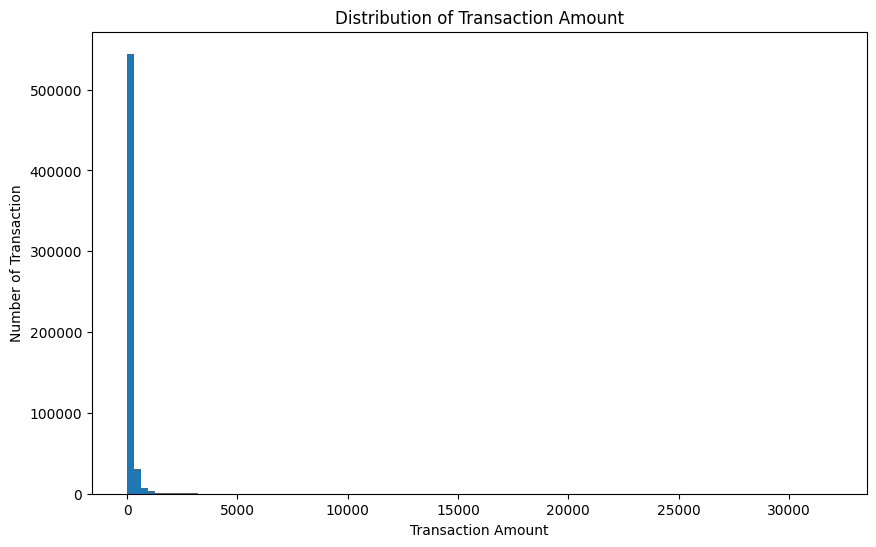

In [38]:
plt.figure (figsize = (10, 6))

plt.hist(
    train_transaction["TransactionAmt"],
    bins = 100
)

plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transaction")
plt.title("Distribution of Transaction Amount")

plt.show()

Most observations are concentrated near the lower transaction amounts, with a long right tail caused by relatively few large transactions.

TransactionAmt is highly concentrated at relatively low values and has a very long right tail. This visually confirms the strong positive skewness of 14.3744 observed earlier. Extreme transaction amounts exist, but we have no basis yet to classify them as erroneous or remove them.

In [39]:
amount_99th = train_transaction["TransactionAmt"].quantile(0.99)
print(f"99th percentile of TransactionAmt: {amount_99th: 2f}")

99th percentile of TransactionAmt:  1104.000000


Approximately 99% of the transactions have TransactionAmt ≤ 1104, and approximately 1% have an amount greater than 1104.

With 590,540 transactions, roughly:

$$ 590540 \times 0.01 \approx 5,905 $$

So approximately 5,905 transactions are above 1104.

And roughly:

$$ 590540 \times 0.99 \approx 584,635 $$

are at or below 1104.

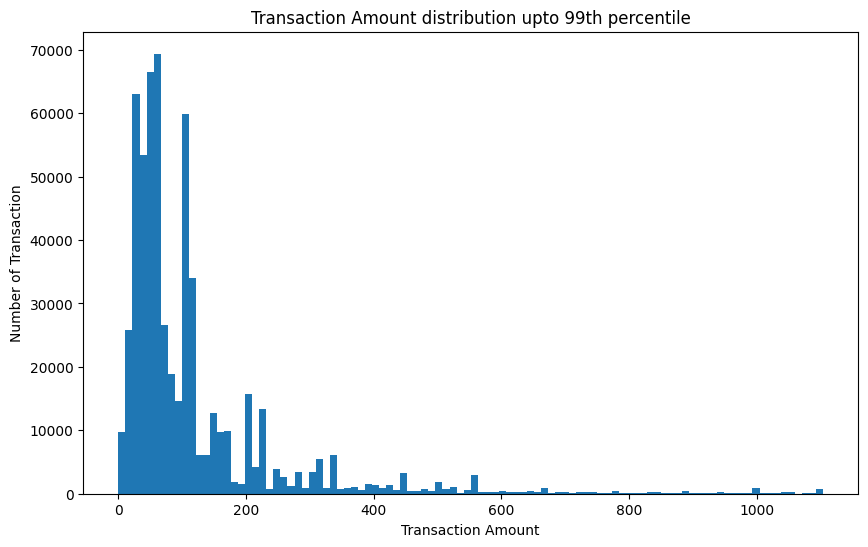

In [40]:
amount_99th = train_transaction["TransactionAmt"].quantile(0.99)

plt.figure (figsize = (10,6))

plt.hist (
    train_transaction["TransactionAmt"],
    bins = 100,
    range=(train_transaction["TransactionAmt"].min(), amount_99th)
)

plt.xlabel ("Transaction Amount")
plt.ylabel ("Number of Transaction")
plt.title ("Transaction Amount distribution upto 99th percentile")

plt.show()

The first thing that stands out is that most transactions are concentrated roughly in the lower transaction-amount range, especially around tens to low hundreds.

Then the frequency drops substantially as the amount increases.

There are also several visible spikes. That's not necessarily noise. It suggests the transaction amounts may not form one smooth distribution. There may be preferred/repeated transaction amounts or discrete pricing patterns in the data.

In [45]:
number_cardinality = (train_transaction[numeric_columns].nunique(dropna = True). sort_values())

number_cardinality.head(30)

V305       2
V1         2
V14        2
V41        2
V107       2
V88        2
V65        2
isFraud    2
V89        3
V68        3
V94        3
V120       4
V27        4
V28        4
V35        4
V12        4
V121       4
V117       4
V118       4
V122       4
V119       4
V75        5
V10        5
V241       5
V50        6
V21        6
V11        6
V240       6
V69        6
V48        6
dtype: int64

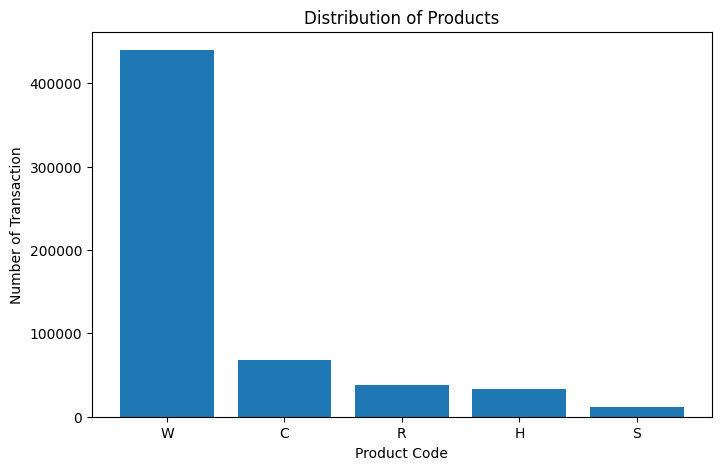

In [46]:
productcd_counts = train_transaction["ProductCD"].value_counts()

plt.figure(figsize = (8,5))

plt.bar(
    productcd_counts.index,
    productcd_counts.values
)

plt.xlabel ("Product Code")
plt.ylabel ("Number of Transaction")
plt.title ("Distribution of Products")

plt.show()

### Inference |

ProductCD is strongly imbalanced acorss its categories.

ProductCD has five categories with a highly uneven distribution. W represents the majority of transactions, while S is relatively rare.

In [47]:
categorical_missing = train_transaction [categorical_columns].isna().sum()
categorical_missing = categorical_missing.sort_values(ascending = False)
categorical_missing

R_emaildomain    453249
M5               350482
M7               346265
M8               346252
M9               346252
M4               281444
M1               271100
M3               271100
M2               271100
M6               169360
P_emaildomain     94456
card4              1577
card6              1571
ProductCD             0
dtype: int64

## Step 4.2 | Bivariate Analysis

Here, we will look in What characteristics distinguish fraudulent transactions from legitimate ones?

Step 4.2.1 | Numerical Features vs Target

C:\Users\sambhav\AppData\Local\Temp\ipykernel_2464\2778545121.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


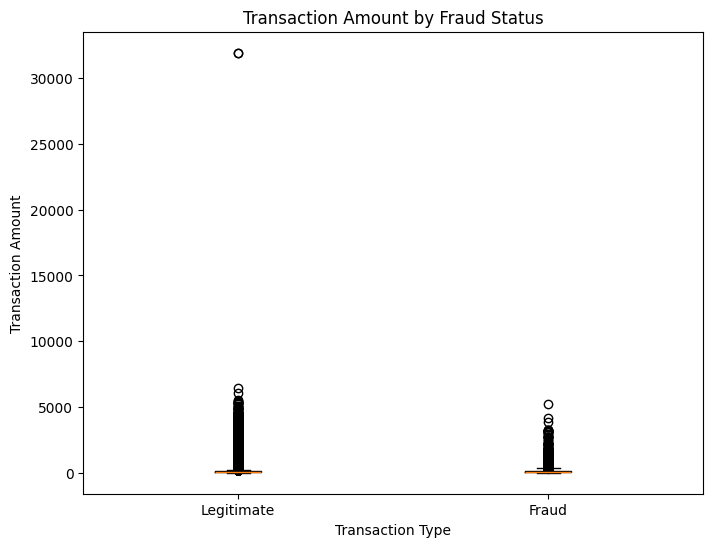

In [48]:
plt.figure (figsize = (8, 6))

plt.boxplot(
    [
        train_transaction.loc[
            train_transaction["isFraud"] == 0,
            "TransactionAmt"
            ],
            train_transaction.loc[
                train_transaction["isFraud"] == 1,
                "TransactionAmt"
            ]
    ],
    labels = ["Legitimate", "Fraud"]
)

plt.xlabel ("Transaction Type")
plt.ylabel ("Transaction Amount")
plt.title ("Transaction Amount by Fraud Status")

plt.show()

Both legitimate and fraudulent transactions are heavily right-skewed, with many high-value observations relative to their central distributions.

C:\Users\sambhav\AppData\Local\Temp\ipykernel_2464\3611372008.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


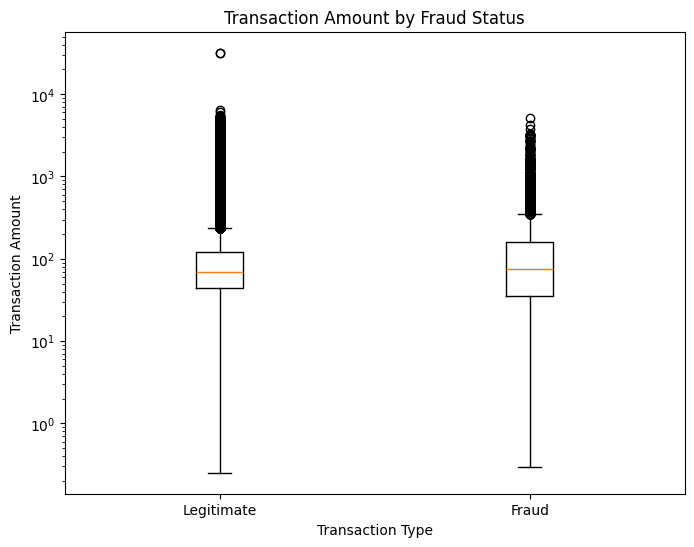

In [49]:
plt.figure (figsize = (8, 6))

plt.boxplot(
    [
        train_transaction.loc[
            train_transaction["isFraud"] == 0,
            "TransactionAmt"
            ],
            train_transaction.loc[
                train_transaction["isFraud"] == 1,
                "TransactionAmt"
            ]
    ],
    labels = ["Legitimate", "Fraud"]
)

plt.yscale("log")

plt.xlabel ("Transaction Type")
plt.ylabel ("Transaction Amount")
plt.title ("Transaction Amount by Fraud Status")

plt.show()

## Inferences

1. Fraud has a slightly higher median. Mean, So fraudulent transactions tend to have a somewhat higher central transaction amount. But the difference is small.
2. The distributions overlap heavily. Mean, TransactionAmt alone cannot cleanly distinguish fraud from legitimate transactions.
3. Fraud has a somewhat wider central spread. Mean, The fraud box appears somewhat taller than the legitimate box.
That suggests greater variability in the central transaction amounts for fraud, although we shouldn't overstate this from a visual alone.
4. The extreme values are still there.

In [50]:
amount_bins = pd.qcut(
    train_transaction["TransactionAmt"],
    q=10,
    duplicates="drop"
)

fraud_rate_by_amount = (
    train_transaction.groupby(amount_bins, observed=True)["isFraud"]
    .agg(
        total_transactions="count",
        fraud_transactions="sum",
        fraud_rate="mean"
    )
)

fraud_rate_by_amount["fraud_rate"] = (
    fraud_rate_by_amount["fraud_rate"] * 100
)

fraud_rate_by_amount

,total_transactions,fraud_transactions,fraud_rate
TransactionAmt,,,
"(0.25, 25.95]",59511,3326,5.588883
"(25.95, 35.95]",61650,1976,3.205191
"(35.95, 49.0]",65116,2100,3.225014
"(49.0, 57.95]",59647,1159,1.943099
"(57.95, 68.769]",49346,1407,2.851295
"(68.769, 100.0]",73349,2653,3.616955
"(100.0, 117.0]",72079,1423,1.974223
"(117.0, 159.95]",32399,1394,4.302602
"(159.95, 275.293]",58390,2221,3.803734


## Inference
Fraud rate is not monotonically increasing with transaction amount. Both very small transactions and very large transactions have relatively high observed fraud rates compared with several middle ranges.

### TransactionDT as a Temporal Feature

lets discuss 
For fraud detection, what we actually care about is:

Does fraud behavior change over time?

In [51]:
transaction_day = train_transaction ["TransactionDT"] / 86400

print (transaction_day.describe())

count    590540.000000
mean         85.327677
std          53.440089
min           1.000000
25%          35.035391
50%          84.566291
75%         130.169213
max         182.999201
Name: TransactionDT, dtype: float64


In [52]:
transaction_day = train_transaction ["TransactionDT"] / 86400

time_bins = pd.cut(
    transaction_day,
    bins = 6
)

fraud_rate_by_time = (
    train_transaction.groupby(time_bins, observed = True)["isFraud"]
    .agg(
        total_transactions="count",
        fraud_transactions="sum",
        fraud_rate="mean"
    )
)

fraud_rate_by_time["fraud_rate"] = (
    fraud_rate_by_time["fraud_rate"] * 100
)

fraud_rate_by_time

,total_transactions,fraud_transactions,fraud_rate
TransactionDT,,,
"(0.818, 31.333]",135222,3472,2.567630
"(31.333, 61.666]",89948,3550,3.946725
"(61.666, 92.0]",94757,3860,4.073578
"(92.0, 122.333]",98305,3866,3.932659
"(122.333, 152.666]",84938,2857,3.363630
"(152.666, 182.999]",87370,3058,3.500057


## Step 4.2.2 | Categorical Features vs Target

In [53]:
fraud_rate_by_product = (
    train_transaction.groupby("ProductCD")["isFraud"]
    .agg(
        total_transactions="count",
        fraud_transactions="sum",
        fraud_rate="mean"
    )
)

fraud_rate_by_product["fraud_rate"] = (
    fraud_rate_by_product["fraud_rate"] * 100
)

fraud_rate_by_product

,total_transactions,fraud_transactions,fraud_rate
ProductCD,,,
C,68519,8008,11.687269
H,33024,1574,4.766231
R,37699,1426,3.782594
S,11628,686,5.899553
W,439670,8969,2.039939


ProductCD C had an observed fraud rate of about 11.7%, compared with only about 2.0% for W. Since W represents most transactions, raw fraud counts would have obscured this relationship. This suggested ProductCD could be an important predictive feature and motivated further investigation of categorical variables.

In [54]:
fraud_rate_by_card4 = (
    train_transaction.groupby("card4")["isFraud"]
    .agg(
        total_transactions="count",
        fraud_transactions="sum",
        fraud_rate="mean"
    )
)

fraud_rate_by_card4["fraud_rate"] = (
    fraud_rate_by_card4["fraud_rate"] * 100
)

fraud_rate_by_card4

,total_transactions,fraud_transactions,fraud_rate
card4,,,
american express,8328,239,2.869837
discover,6651,514,7.728161
mastercard,189217,6496,3.433095
visa,384767,13373,3.475610


In this dataset, transactions associated with Discover have a substantially higher observed fraud rate.

In [55]:
fraud_rate_by_card6 = (
    train_transaction.groupby("card6")["isFraud"]
    .agg(
        total_transactions="count",
        fraud_transactions="sum",
        fraud_rate="mean"
    )
)

fraud_rate_by_card6["fraud_rate"] = (
    fraud_rate_by_card6["fraud_rate"] * 100
)

fraud_rate_by_card6

,total_transactions,fraud_transactions,fraud_rate
card6,,,
charge card,15,0,0.000000
credit,148986,9950,6.678480
debit,439938,10674,2.426251
debit or credit,30,0,0.000000


In [56]:
m_features = [f"M{i}" for i in range(1, 10)]

m_fraud_summary = []

for feature in m_features:
    summary = (
        train_transaction.groupby(feature, dropna=False)["isFraud"]
        .agg(
            total_transactions="count",
            fraud_transactions="sum",
            fraud_rate="mean"
        )
        .reset_index()
    )

    summary.insert(0, "Feature", feature)
    summary["fraud_rate"] = summary["fraud_rate"] * 100

    m_fraud_summary.append(summary)

m_fraud_summary = pd.concat(
    m_fraud_summary,
    ignore_index=True
)

m_fraud_summary

,Feature,M1,total_transactions,fraud_transactions,fraud_rate,M2,M3,M4,M5,M6,M7,M8,M9
0,M1,F,25,0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,M1,T,319415,6342,1.985505,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,M1,NaN,271100,14321,5.282553,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,M2,NaN,33972,1184,3.485223,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,M2,NaN,285468,5158,1.806858,T,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,M2,NaN,271100,14321,5.282553,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,M3,NaN,67709,2049,3.026186,NaN,F,NaN,NaN,NaN,NaN,NaN,NaN
7,M3,NaN,251731,4293,1.705392,NaN,T,NaN,NaN,NaN,NaN,NaN,NaN
8,M3,NaN,271100,14321,5.282553,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,M4,NaN,196405,7198,3.664876,NaN,NaN,M0,NaN,NaN,NaN,NaN,NaN


In [57]:
email_features = ["P_emaildomain", "R_emaildomain"]

email_fraud_summary = []

for feature in email_features:
    email_status = train_transaction[feature].isna().map({
        True: "Missing",
        False: "Present"
    })

    summary = (
        train_transaction.groupby(email_status)["isFraud"]
        .agg(
            total_transactions="count",
            fraud_transactions="sum",
            fraud_rate="mean"
        )
        .reset_index()
    )

    summary.insert(0, "Feature", feature)
    summary = summary.rename(columns={feature: "status"})
    summary["fraud_rate"] = (summary["fraud_rate"] * 100).round(2)

    email_fraud_summary.append(summary)

email_fraud_summary = pd.concat(
    email_fraud_summary,
    ignore_index=True
)

email_fraud_summary

,Feature,status,total_transactions,fraud_transactions,fraud_rate
0,P_emaildomain,Missing,94456,2790,2.95
1,P_emaildomain,Present,496084,17873,3.60
2,R_emaildomain,Missing,453249,9436,2.08
3,R_emaildomain,Present,137291,11227,8.18


### Observation:
1. TransactionAmt is heavily right-skewed.
2. TransactionDT represents time and shows temporal variation in fraud rate.
3. Several categorical variables have missing values.
4. Missingness itself may contain fraud signal.Some categorical groups have very uneven distributions.
5. The fraud target is highly imbalanced.

## Step 5 | Data Preprocessing

In [58]:
train_transaction.shape

(590540, 394)

### Step 5.1 | Irrelevant Features Removal

We should not start deleting columns just because there are 394 of them. 394 features is not inherently a problem.

There are three different reasons a feature might eventually be removed:

1. Target leakage: The feature contains information that wouldn't be available when making the fraud decision.
2. Pure identifier / administrative field: It identifies a transaction or record but doesn't represent a meaningful predictive characteristic.
3. Practically unusable feature: For example, a feature with almost no usable observations or some other structural problem.

In [59]:
train_transaction["TransactionID"].nunique()

590540

In [60]:
model_data = train_transaction.copy()

In [61]:
model_data = model_data.drop(columns = ["TransactionID"])

In [62]:
"TransactionID" in model_data.columns

False

### Removing TransactionID

`TransactionID` is a unique identifier, with 590,540 unique values across
590,540 transactions. It does not represent a meaningful transactional
characteristic and is therefore excluded from the model features.

The original `train_transaction` DataFrame is preserved so that
`TransactionID` remains available for transaction identification and
future reporting.

In [63]:
card_features = ["card1", "card2", "card3", "card5"]

card_feature_info = (
    model_data[card_features]
    .nunique(dropna = True).sort_values()
)

card_feature_info

card3      114
card5      119
card2      500
card1    13553
dtype: int64

In [64]:
v_features = [col for col in model_data.columns if col.startswith("V")]

v_missing_summary = (
    model_data[v_features]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

v_missing_summary.head(20)

V153    86.123717
V146    86.123717
V142    86.123717
V141    86.123717
V163    86.123717
V148    86.123717
V149    86.123717
V155    86.123717
V154    86.123717
V157    86.123717
V156    86.123717
V158    86.123717
V161    86.123717
V139    86.123717
V140    86.123717
V147    86.123717
V138    86.123717
V162    86.123717
V150    86.122701
V160    86.122701
dtype: float64

In [65]:
constant_features = [
    col for col in model_data.columns
    if model_data[col].nunique(dropna=False) <= 1
]

constant_features

[]

### Step 5.2 | Missing Value Treatment

In [66]:
missing_summary = model_data.isna().sum().to_frame("missing_count")

missing_summary ["missing_pct"] = (missing_summary["missing_count"] / len(model_data)*100)

missing_summary = (missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_pct", ascending = False))

missing_summary

,missing_count,missing_pct
dist2,552913,93.628374
D7,551623,93.409930
D13,528588,89.509263
D14,528353,89.469469
D12,525823,89.041047
...,...,...
V302,12,0.002032
V303,12,0.002032
V304,12,0.002032
V305,12,0.002032


In [67]:
numerical_feature = model_data.select_dtypes(
    include = ["int64", "float64"]
).columns

categorical_feature = model_data.select_dtypes(
    include = ["object"]
).columns

print("\nNumerical Feature:", len(numerical_feature))
print("\nCategorical Feature:", len(categorical_feature))

print("\nNumerical Features with missing Values:", model_data[numerical_feature].isna().any().sum())
print("\nCategorical Features with missing Values:", model_data[categorical_feature].isna().any().sum())


Numerical Feature: 379

Categorical Feature: 14

Numerical Features with missing Values: 361

Categorical Features with missing Values: 13


In [69]:
numerical_missing_summary = (model_data[numerical_feature].isna().mean().mul(100).sort_values(ascending=False))

numerical_missing_summary.head(20)

dist2    93.628374
D7       93.409930
D13      89.509263
D14      89.469469
D12      89.041047
D6       87.606767
D9       87.312290
D8       87.312290
V153     86.123717
V138     86.123717
V139     86.123717
V157     86.123717
V140     86.123717
V141     86.123717
V162     86.123717
V155     86.123717
V147     86.123717
V146     86.123717
V149     86.123717
V156     86.123717
dtype: float64

In [70]:
sparse_feature = numerical_missing_summary[numerical_missing_summary >= 80].index

sparse_missing_fraud = []

for feature in sparse_feature:
    missing_status = model_data[feature].isna().map({
        True: "Missing",
        False: "Present",
    })

    summary= (
        model_data.groupby(missing_status)["isFraud"]
        .agg(
            total_transaction = "count",
            fraud_transaction = "sum",
            fraud_rate = "mean"
        ).reset_index()
    )

    summary.insert(0, "Feature", feature)
    summary = summary.rename(columns = {feature: "status"})
    summary["fraud_rate"] = (
        summary["fraud_rate"] * 100
    ).round(2)


    sparse_missing_fraud.append(summary)

sparse_missing_fraud = pd.concat(
    sparse_missing_fraud,
    ignore_index=True
)

sparse_missing_fraud    

,Feature,status,total_transaction,fraud_transaction,fraud_rate
0,dist2,Missing,552913,16932,3.06
1,dist2,Present,37627,3731,9.92
2,D7,Missing,551623,14873,2.70
3,D7,Present,38917,5790,14.88
4,D13,Missing,528588,13826,2.62
...,...,...,...,...,...
105,V335,Present,82351,3686,4.48
106,V332,Missing,508189,16977,3.34
107,V332,Present,82351,3686,4.48
108,V331,Missing,508189,16977,3.34


### Inference

The analysis shows that missingness in highly sparse numerical features is
associated with different fraud rates.

For example, `dist2` has a fraud rate of 3.06% when the value is missing,
but 9.92% when it is present. Similarly, `D7` has a fraud rate of 2.70%
when missing compared with 14.88% when present. This indicates that the
presence or absence of these features may itself contain useful information
for fraud detection.

Therefore, high missingness alone should not be used as a reason to remove
these features. Instead, these features will be retained and their
missingness information will be preserved during preprocessing. The actual
missing values will be treated separately rather than blindly replacing
them without considering the information carried by missingness.

These results represent an association observed in the dataset and do not
imply that the presence of a feature causes fraud.

In [71]:
missing_bins = pd.cut(
    numerical_missing_summary,
    bins=[0, 20, 50, 80, 100],
    labels=["Low", "Moderate", "High", "Extreme"],
    include_lowest=True
)

missing_distribution = (
    missing_bins
    .value_counts()
    .reindex(["Low", "Moderate", "High", "Extreme"])
    .to_frame("number_of_features")
)

missing_distribution

,number_of_features
Low,177
Moderate,33
High,114
Extreme,55


In [72]:
model_data = model_data.sort_values("TransactionDT").reset_index(drop=True)

split_index = int(len(model_data) * 0.80)

train_data = model_data.iloc[:split_index].copy()
validation_data = model_data.iloc[split_index:].copy()

print("Training data:", train_data.shape)
print("Validation data:", validation_data.shape)

print("\nTraining period:")
print(train_data["TransactionDT"].min(), "to", train_data["TransactionDT"].max())

print("\nValidation period:")
print(validation_data["TransactionDT"].min(), "to", validation_data["TransactionDT"].max())

Training data: (472432, 393)
Validation data: (118108, 393)

Training period:
86400 to 12192842

Validation period:
12192900 to 15811131


### Step 5.2.1 | Train-Validation Split

Before applying any preprocessing technique that learns information from the data, such as imputation, scaling, or encoding, the dataset must be divided into training and validation sets.

Because this is a fraud-detection problem and our EDA showed that fraud rates vary over time, a chronological split is more appropriate than a random split. The model will therefore be trained using earlier transactions and evaluated on later transactions, which better represents a real-world deployment scenario.

The training set will be used to learn preprocessing parameters, while the validation set will remain unseen during this process. This prevents information from the validation period from leaking into the training pipeline.

In [73]:
X_train = train_data.drop(columns=["isFraud"])
y_train = train_data["isFraud"]

X_validation = validation_data.drop(columns=["isFraud"])
y_validation = validation_data["isFraud"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_validation:", X_validation.shape)
print("y_validation:", y_validation.shape)

X_train: (472432, 392)
y_train: (472432,)
X_validation: (118108, 392)
y_validation: (118108,)


### Inference:

The dataset has been successfully separated into features (X) and target (y) while preserving the chronological train-validation split.

1. X_train contains 472,432 transactions and 392 features.
2. y_train contains the corresponding 472,432 fraud labels.
3. X_validation contains 118,108 later transactions and the same 392 features.
4. y_validation contains their corresponding 118,108 fraud labels.

### Step 5.2.2 | Numerical Missing Value Treatment

Our initial strategy

For numerical features, we'll use median imputation.

Why median rather than mean?

Because our EDA showed that transaction-related numerical variables can be skewed. The median is much less affected by extreme values.

In [74]:
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Numerical features:", len(numerical_features))

Numerical features: 378


### Inference

We decide to use Median Imputation for numerical features because:
1. Many numerical variables are skewed.
2. Median is less sensitive to extreme values.
3. It gives us a consistent, reproducible treatment.
4. Scikit-Learn's SimpleImputer lets us fit the treatment on training data only.

In [75]:
import gc

del model_data
del train_data
del validation_data

gc.collect()

10324

In [76]:
X_train[numerical_features].memory_usage(deep=True).sum() / (1024 ** 3)

np.float64(1.3305195607244968)

In [77]:
from sklearn.impute import SimpleImputer
import numpy as np

X_train_numeric = X_train[numerical_features].to_numpy(
    dtype=np.float32
)

numerical_imputer = SimpleImputer(
    strategy="median"
)

numerical_imputer.fit(X_train_numeric)

print("Numerical imputer fitted successfully.")
print("Features processed:", len(numerical_features))

Numerical imputer fitted successfully.
Features processed: 378


In [78]:
del X_train_numeric
import gc
gc.collect()

0

In [79]:
X_train[numerical_features] = numerical_imputer.transform(
    X_train[numerical_features]
)

X_validation[numerical_features] = numerical_imputer.transform(
    X_validation[numerical_features]
)

C:\Users\sambhav\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(
C:\Users\sambhav\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(


In [80]:
print(
    "Missing numerical values in X_train:",
    X_train[numerical_features].isna().sum().sum()
)

print(
    "Missing numerical values in X_validation:",
    X_validation[numerical_features].isna().sum().sum()
)

Missing numerical values in X_train: 0
Missing numerical values in X_validation: 0


### Inference

Median imputation was successfully applied to all 378 numerical features.
The imputation values were learned exclusively from the training dataset
and then applied to both the training and validation datasets.

After transformation, both datasets contain zero missing numerical values.
This confirms that the numerical missing-value treatment was completed
without using validation data to calculate the imputation values, thereby
avoiding data leakage.

### Step 5.2.3 | Categorical Missing Value Treatment

In [81]:
categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

for feature in categorical_features:
    X_train[feature] = X_train[feature].fillna("Missing")
    X_validation[feature] = X_validation[feature].fillna("Missing")

print("Categorical features processed:", len(categorical_features))

Categorical features processed: 14


### Inference

The missing values in the categorical features have been replaced with the explicit category "Missing". This preserves the distinction between an actually observed category and an unavailable value, which is important because our earlier EDA showed that missingness can itself be associated with fraud.

In [82]:
print(
    "Missing categorical values in X_train:",
    X_train[categorical_features].isna().sum().sum()
)

print(
    "Missing categorical values in X_validation:",
    X_validation[categorical_features].isna().sum().sum()
)

Missing categorical values in X_train: 0
Missing categorical values in X_validation: 0


## Step 5.3 | Outlier Treatment

An extreme value is not automatically a bad value. It could be the fraud signal we're trying to detect.

Our approach:

We'll first identify potentially extreme numerical features, then determine whether those extremes look like legitimate observations or data-quality problems.

### Step 5.3.1 | Identify Extreme Numerical Values

In [83]:
outlier_summary = []

for feature in numerical_features:
    q1 = X_train[feature].quantile(0.25)
    q3 = X_train[feature].quantile(0.75)

    iqr = q3 - q1

    upper_bound = q3 + 1.5 * iqr

    outlier_count = (X_train[feature] > upper_bound).sum()

    outlier_pct = (
        outlier_count / len(X_train) * 100
    )

    outlier_summary.append({
        "feature": feature,
        "outlier_count": outlier_count,
        "outlier_pct": outlier_pct
    })

outlier_summary = (
    pd.DataFrame(outlier_summary)
    .sort_values("outlier_pct", ascending=False)
)

outlier_summary.head(20)

,feature,outlier_count,outlier_pct
341,V303,117724,24.918718
342,V304,117432,24.856911
340,V302,117138,24.794679
13,C4,114914,24.323924
19,C10,114659,24.269948
34,D11,112882,23.893809
25,D2,111914,23.688912
28,D5,106209,22.481331
166,V128,104872,22.198327
135,V97,104872,22.198327


### Inference

The IQR-based outlier analysis identified a large proportion of observations as potential outliers for several numerical features. For example, more than
24% of the training observations were flagged for `V303`, `V304`, and `V302`.

Such a high proportion indicates that the standard IQR rule is not suitable as a blanket outlier-removal criterion for this dataset. These observations
may represent legitimate variation, skewed distributions, or meaningful transaction patterns rather than erroneous data.

Since this is a fraud-detection problem, extreme values may themselves contain valuable fraud-related information. Therefore, observations will
not be removed solely because they exceed the IQR-based threshold.

Outlier treatment will instead focus on appropriate transformations or modeling techniques where necessary, while preserving potentially
informative transaction observations.

In [84]:
transaction_amt_summary = X_train["TransactionAmt"].describe(
    percentiles=[0.50, 0.95, 0.99]
)

transaction_amt_summary

count    472432.000000
mean        134.401388
std         237.557972
min           0.251000
50%          68.950000
95%         441.950000
99%        1104.000000
max       31937.391000
Name: TransactionAmt, dtype: float64

### Inference

TransactionAmt has a strong right-skewed distribution:

1. Median: 68.95
2. Mean: 134.40
3. 95th percentile: 441.95
4. 99th percentile: 1,104
5. Maximum: 31,937.39

### Inference

`TransactionAmt` shows a strongly right-skewed distribution. The median
transaction amount is 68.95, while the mean is considerably higher at
134.40. The 99th percentile is 1,104, compared with a maximum of 31,937.39,
indicating a long upper tail.

However, high transaction amounts are not necessarily erroneous values.
In fraud detection, unusually large transactions may represent legitimate
high-value purchases as well as potentially fraudulent activity. Removing
or capping these observations could therefore eliminate useful fraud-related
information.

Consequently, no observations will be removed solely because of their
extreme transaction amount. The skewed distribution may instead be addressed
through an appropriate transformation during a later preprocessing stage.

## Step 5.4 | Categorical Encoding

We now move from outlier treatment to categorical encoding. As, Machine-learning models generally need these categories represented numerically.

### Step 5.4.1 | Categorical Cardinality Audit

We'll check the number of unique categories after our missing-value treatment.

In [85]:
categorical_cardinality = (
    X_train[categorical_features]
    .nunique(dropna=False)
    .sort_values(ascending=False)
)

categorical_cardinality

R_emaildomain    61
P_emaildomain    60
card4             5
ProductCD         5
card6             5
M4                4
M1                3
M2                3
M3                3
M5                3
M6                3
M7                3
M8                3
M9                3
dtype: int64

### Inference

Our 14 categorical features have relatively low cardinality.

1. R_emaildomain → 61 categories
2. P_emaildomain → 60 categories
3. card4, ProductCD, card6 → 5 categories each
4. M4 → 4 categories
5. M1-M3, M5-M9 → 3 categories each

### Inference

The categorical features have relatively low cardinality, with the highest
number of categories being 61 for `R_emaildomain` and 60 for
`P_emaildomain`. The remaining categorical features contain between 3 and 5
categories.

Since these features do not have a natural ordinal relationship, one-hot
encoding is appropriate. This converts each category into a separate binary
feature without introducing an artificial numerical ordering.

The relatively low cardinality also means that one-hot encoding will not
cause an excessive increase in dimensionality. Therefore, all 14 categorical
features will be encoded using OneHotEncoder, with unseen validation
categories handled safely.

In [86]:
from sklearn.preprocessing import OneHotEncoder

categorical_encoder = OneHotEncoder (
    handle_unknown = "ignore",
    sparse_output = True
)

categorical_encoder.fit(X_train[categorical_features])

print("Categorical encoder fitted successfully.")
print("Categorical features processed:", len(categorical_features))

Categorical encoder fitted successfully.
Categorical features processed: 14


### Inference

The OneHotEncoder was successfully fitted on all 14 categorical features in X_train.

The encoder has learned the categories present in the training data and is configured to:

1. Ignore unseen categories in validation data rather than producing an error.
2. Produce a sparse matrix, which is important given your 8 GB RAM constraint.
3. Preserve the categorical information without imposing an artificial numerical ordering.

### Step 5.4.4 | Transform Categorical Features

In [87]:
X_train_cat = categorical_encoder.transform(
    X_train[categorical_features]
)

X_validation_cat = categorical_encoder.transform(
    X_validation[categorical_features]
)

print("Encoded training shape:", X_train_cat.shape)
print("Encoded validation shape:", X_validation_cat.shape)

Encoded training shape: (472432, 164)
Encoded validation shape: (118108, 164)


### Step 5.4.5 | Combine Numerical and Categorical Features

In [88]:
from scipy.sparse import csr_matrix, hstack

X_train_num = csr_matrix(
    X_train[numerical_features].to_numpy(dtype=np.float32)
)

X_validation_num = csr_matrix(
    X_validation[numerical_features].to_numpy(dtype=np.float32)
)

X_train_final = hstack(
    [X_train_num, X_train_cat],
    format="csr"
)

X_validation_final = hstack(
    [X_validation_num, X_validation_cat],
    format="csr"
)

print("Final training shape:", X_train_final.shape)
print("Final validation shape:", X_validation_final.shape)

Final training shape: (472432, 542)
Final validation shape: (118108, 542)


### Inference

The numerical and categorical features have been successfully combined into the final modeling representation.

The final feature space contains:

$$ 378\text{ numerical} + 164\text{ encoded categorical} = 542\text{ features} $$

for both training and validation:

### Step 5.4.6 | Verify Final Feature Matrices

In [89]:
print("X_train_final:", X_train_final.shape)
print("y_train:", y_train.shape)

print("X_validation_final:", X_validation_final.shape)
print("y_validation:", y_validation.shape)

print("\nX_train_final type:", type(X_train_final))
print("X_validation_final type:", type(X_validation_final))

X_train_final: (472432, 542)
y_train: (472432,)
X_validation_final: (118108, 542)
y_validation: (118108,)

X_train_final type: <class 'scipy.sparse._csr.csr_matrix'>
X_validation_final type: <class 'scipy.sparse._csr.csr_matrix'>


### Inference

The numerical and one-hot encoded categorical features were successfully
combined into the final sparse feature matrices. The resulting training
dataset contains 472,432 transactions with 542 features, while the
validation dataset contains 118,108 transactions with the same 542 features.

The target vectors contain the corresponding number of fraud labels.
Both feature matrices are stored as CSR sparse matrices, providing a
memory-efficient representation of the one-hot encoded feature space.

The identical feature dimensionality between training and validation
confirms that the same preprocessing structure has been applied to both
datasets.

## Step 5.5 | Feature Scaling

__Feature Scaling__ is a crucial preprocessing step __for algorithms that are sensitive to the magnitude or scale of features__. Models like __SVM__, __KNN__, and many linear models rely on distances or gradients, making them susceptible to variations in feature scales. __Scaling ensures that all features contribute equally to the model's decision rather than being dominated by features with larger magnitudes.__

____
### Why We Skip It Now:

While feature scaling is vital for some models, not all algorithms require scaled data. For instance, __Decision Tree-based models__ are scale-invariant. Given our intent to use a mix of models (some requiring scaling, others not), __we've chosen to handle scaling later using pipelines__. This approach lets us apply scaling specifically for models that benefit from it, ensuring flexibility and efficiency in our modeling process.

## Step 5.6 | Skewness Transformation.

In [90]:
skewness_summary = (
    X_train[numerical_features]
    .skew()
    .sort_values(key=abs, ascending=False)
)

skewness_summary.head(20)

V206    414.025531
V334    410.223239
V336    386.789007
V269    365.552373
V266    361.679745
V305    343.665171
V311    324.666461
V335    313.125896
V129    251.075229
V214    250.466874
V309    235.144903
V276    225.802601
V331    220.847039
V333    212.509833
V278    206.058590
V241    201.125444
V227    196.045358
V337    195.297292
V216    192.958697
V339    192.577459
dtype: float64

## Step 6 | Model Building & Comparison

### Step 6.1 | Model 1: Logistic Regression Baseline

In [91]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline([
    ("Scaler", StandardScaler(with_mean= False)),
    (
        "model",
        LogisticRegression(
            class_weight = "balanced",
            max_iter = 1000,
            solver = "liblinear"
        )
    )
])

logistic_pipeline.fit(X_train_final, y_train)

print("Logistic Regression trained Successfully.")

Logistic Regression trained Successfully.


In [92]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    roc_auc_score,
    confusion_matrix
)

# Generate predictions
y_validation_pred = logistic_pipeline.predict(
    X_validation_final
)

# Generate probability scores for PR-AUC and ROC-AUC
y_validation_proba = logistic_pipeline.predict_proba(
    X_validation_final
)[:, 1]

# Calculate metrics
precision = precision_score(
    y_validation,
    y_validation_pred
)

recall = recall_score(
    y_validation,
    y_validation_pred
)

f1 = f1_score(
    y_validation,
    y_validation_pred
)

pr_auc = average_precision_score(
    y_validation,
    y_validation_proba
)

roc_auc = roc_auc_score(
    y_validation,
    y_validation_proba
)

cm = confusion_matrix(
    y_validation,
    y_validation_pred
)

print("Logistic Regression Baseline Results")
print("------------------------------------")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(cm)

Logistic Regression Baseline Results
------------------------------------
Precision : 0.0984
Recall    : 0.7729
F1 Score  : 0.1746
PR-AUC    : 0.1841
ROC-AUC   : 0.8310

Confusion Matrix:
[[85262 28782]
 [  923  3141]]


### Inference from the Logistic Regression Baseline

The most important conclusion is:

> **The model can detect fraud, but its current decision rule is too aggressive.**

Here's what the numbers tell us.

### 1. Recall = 77.29% → Strong

- It caught **3,141 of 4,064 fraudulent transactions**.
- Only **923 frauds were missed**.
- Therefore, the model is genuinely learning useful fraud patterns.

### 2. Precision = 9.84% → Major Weakness

- It flagged **31,923 transactions** as fraud.
- Only **3,141 were actually fraud**.
- Therefore, **28,782 legitimate transactions were incorrectly flagged**.
- In a real payment system, this could create substantial customer friction.

### 3. ROC-AUC = 0.831 → Encouraging

- The model has a reasonably good ability to rank risky transactions above legitimate ones.
- This is important because it suggests that the underlying model is not useless; the **final binary decision rule is part of the problem**.

### 4. PR-AUC = 0.1841 → Weak/Modest

- For this highly imbalanced fraud-detection problem, PR-AUC is more informative than accuracy.
- There is significant room for a stronger model to improve the precision–recall relationship.

### 5. F1 = 0.1746 → Not Good Enough

- The large gap between precision and recall explains the low F1 score.
- We have good fraud capture, but we are paying for it with too many false alarms.

---

### Key Insight

Our baseline is **not** saying:

> "Logistic Regression doesn't work."

Instead, it is saying:

> **"Logistic Regression has learned useful fraud patterns, but the current combination of the model, class weighting, and default decision threshold produces too many false positives."**

This is a valuable baseline finding.

### Baseline Benchmark

| Metric | Score |
|---|---:|
| Precision | **9.84%** |
| Recall | **77.29%** |
| F1 Score | **17.46%** |
| PR-AUC | **18.41%** |
| ROC-AUC | **83.10%** |

**Overall verdict: 🟠 Promising baseline, but far from our final target.**

The next stages should therefore investigate whether we can improve the underlying model through **hyperparameter tuning**, followed later by **threshold optimization** and **business-cost optimization**.

### Planned Optimization Sequence

```text
Baseline Logistic Regression
            ↓
Hyperparameter Tuning
            ↓
Model Comparison
            ↓
Threshold Optimization
            ↓
Business-Cost Optimization
            ↓
Final Fraud Detection System

In [93]:
import numpy as np

print("Prediction Probability Summary")
print("------------------------------")
print(f"Minimum : {y_validation_proba.min():.4f}")
print(f"25th %  : {np.percentile(y_validation_proba, 25):.4f}")
print(f"Median  : {np.percentile(y_validation_proba, 50):.4f}")
print(f"75th %  : {np.percentile(y_validation_proba, 75):.4f}")
print(f"95th %  : {np.percentile(y_validation_proba, 95):.4f}")
print(f"99th %  : {np.percentile(y_validation_proba, 99):.4f}")
print(f"Maximum : {y_validation_proba.max():.4f}")

print("\nThreshold = 0.50")
print(
    "Transactions predicted as fraud:",
    (y_validation_proba >= 0.50).sum()
)

Prediction Probability Summary
------------------------------
Minimum : 0.0000
25th %  : 0.1527
Median  : 0.3172
75th %  : 0.5215
95th %  : 0.8704
99th %  : 1.0000
Maximum : 1.0000

Threshold = 0.50
Transactions predicted as fraud: 31923


The Logistic Regression model has learned useful signal, but its current operating point is too aggressive and its overall ranking quality still has considerable room for improvement. This makes it a valid baseline—and gives us a clear target for tuning and stronger models.

In [94]:
# Chronological split of the training data for hyperparameter tuning

tuning_split = int(X_train_final.shape[0] * 0.80)

X_tune_train = X_train_final[:tuning_split]
X_tune_validation = X_train_final[tuning_split:]

y_tune_train = y_train.iloc[:tuning_split]
y_tune_validation = y_train.iloc[tuning_split:]

print("Tuning training shape:", X_tune_train.shape)
print("Tuning validation shape:", X_tune_validation.shape)

print("\nTuning training target shape:", y_tune_train.shape)
print("Tuning validation target shape:", y_tune_validation.shape)

Tuning training shape: (377945, 542)
Tuning validation shape: (94487, 542)

Tuning training target shape: (377945,)
Tuning validation target shape: (94487,)


In [95]:
from sklearn.metrics import average_precision_score
from sklearn.linear_model import LogisticRegression

def tune_logistic_regression(C_values):
    
    results = []
    
    for C_value in C_values:
        
        print(f"Training Logistic Regression with C={C_value}...")
        
        model = Pipeline([
            ("scaler", StandardScaler(with_mean=False)),
            (
                "model",
                LogisticRegression(
                    C=C_value,
                    class_weight="balanced",
                    max_iter=1000,
                    solver="liblinear"
                )
            )
        ])
        
        # Train on the earlier portion
        model.fit(
            X_tune_train,
            y_tune_train
        )
        
        # Predict probabilities on the later portion
        y_tune_proba = model.predict_proba(
            X_tune_validation
        )[:, 1]
        
        # Evaluate using PR-AUC
        pr_auc = average_precision_score(
            y_tune_validation,
            y_tune_proba
        )
        
        results.append({
            "C": C_value,
            "PR-AUC": pr_auc
        })
        
        print(f"PR-AUC: {pr_auc:.4f}\n")
    
    results = sorted(
        results,
        key=lambda x: x["PR-AUC"],
        reverse=True
    )
    
    return results

In [96]:
from sklearn.model_selection import TimeSeriesSplit

time_cv = TimeSeriesSplit(
    n_splits=5
)

print("Time-aware cross-validation created successfully.")
print("Number of splits:", time_cv.n_splits)

Time-aware cross-validation created successfully.
Number of splits: 5


In [97]:
from sklearn.model_selection import GridSearchCV

def tune_classifier(
    estimator,
    param_grid,
    X,
    y,
    cv,
    scoring="average_precision"
):
    """
    Tune a classifier using time-aware cross-validation.

    Parameters
    ----------
    estimator : sklearn estimator or Pipeline
        Model to tune.

    param_grid : dict
        Hyperparameter combinations to evaluate.

    X : array-like
        Training features.

    y : array-like
        Training target.

    cv : cross-validation strategy
        Validation strategy used during tuning.

    scoring : str
        Metric used to select the best configuration.

    Returns
    -------
    best_estimator : sklearn estimator
        Best fitted model.

    best_params : dict
        Best hyperparameter combination.

    cv_results : dict
        Detailed cross-validation results.
    """

    grid_search = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring=scoring,
        cv=cv,
        refit=True,
        n_jobs=1
    )

    grid_search.fit(X, y)

    return (
        grid_search.best_estimator_,
        grid_search.best_params_,
        grid_search.cv_results_
    )

print("General hyperparameter tuning function created successfully.")

General hyperparameter tuning function created successfully.


In [98]:
logistic_pipeline_tuning = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    (
        "model",
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            solver="liblinear"
        )
    )
])

logistic_param_grid = {
    "model__C": [0.01, 0.1, 1, 10]
}

print("Logistic Regression tuning pipeline created.")
print("Hyperparameter values to test:", logistic_param_grid["model__C"])

Logistic Regression tuning pipeline created.
Hyperparameter values to test: [0.01, 0.1, 1, 10]


In [99]:
time_cv_small = TimeSeriesSplit(
    n_splits=3
)

logistic_param_grid_small = {
    "model__C": [0.1, 1, 10]
}

print("Optimized Logistic Regression tuning setup created.")
print("C values:", logistic_param_grid_small["model__C"])
print("CV splits:", time_cv_small.n_splits)
print("Total model fits:", 3 * 3)

Optimized Logistic Regression tuning setup created.
C values: [0.1, 1, 10]
CV splits: 3
Total model fits: 9


In [100]:
best_logistic, best_logistic_params, logistic_cv_results = tune_classifier(
    estimator=logistic_pipeline_tuning,
    param_grid=logistic_param_grid_small,
    X=X_train_final,
    y=y_train,
    cv=time_cv_small,
    scoring="average_precision"
)

print("Logistic Regression tuning completed.")
print("Best parameters:", best_logistic_params)
print("Best CV PR-AUC:", logistic_cv_results["mean_test_score"].max())

Logistic Regression tuning completed.
Best parameters: {'model__C': 10}
Best CV PR-AUC: 0.4018681617664928


## Logistic Regression — Hyperparameter Tuning: Inferences & Observations

### Observations

1. **Time-aware cross-validation was used**
   - The model was tuned using `TimeSeriesSplit` with 3 folds instead of random cross-validation.
   - This preserves the chronological structure of transaction data and reduces the risk of future information influencing past predictions.

2. **Three regularization values were evaluated**
   - `C = 0.1`
   - `C = 1`
   - `C = 10`

3. **PR-AUC was used as the primary tuning metric**
   - Since fraud detection is a highly imbalanced classification problem, Average Precision (PR-AUC) is more informative than accuracy for model selection.

4. **The best hyperparameter was `C = 10`**
   - Best parameters: `{'model__C': 10}`

5. **The best mean cross-validation PR-AUC was approximately 0.4019**
   - Best CV PR-AUC: `0.401868`

### Inferences

- The Logistic Regression model performed best with `C = 10` among the tested values.
- This indicates that, within the tested range, the model benefited from **weaker regularization**, allowing it to retain more information from the available features.
- Since `C = 10` was the largest value tested, the optimal value could potentially be higher. However, expanding the search is not necessary at this stage because the main objective is to evaluate whether the selected configuration generalizes to unseen future transactions.
- The CV PR-AUC of approximately **0.4019** indicates that the tuned Logistic Regression model has meaningful ability to distinguish and rank fraudulent transactions within the time-aware development folds.
- The CV PR-AUC of `0.4019` should **not be directly compared** with the baseline validation PR-AUC of `0.1841`, because they were calculated on different datasets.
- The final assessment must therefore be performed on the **untouched chronological validation set**.

### Baseline vs Tuning Context

The original Logistic Regression baseline achieved:

| Metric | Baseline |
|---|---:|
| PR-AUC | 0.1841 |
| ROC-AUC | 0.8310 |
| Precision | 0.0984 |
| Recall | 0.7729 |
| F1 Score | 0.1746 |

The tuned model achieved a **CV PR-AUC of 0.4019**. This looks substantially higher than the baseline PR-AUC, but it is not yet evidence of improved final performance because the two scores come from different evaluation datasets.

### Overall Conclusion

> **Hyperparameter tuning selected `C = 10` as the best Logistic Regression configuration, achieving a mean time-aware CV PR-AUC of approximately 0.4019. This suggests that weaker regularization improved the model's ability to rank fraudulent transactions within the development folds. However, the true improvement in generalization must be determined by evaluating the tuned model on the completely untouched chronological validation set.**

In [101]:
y_validation_pred_tuned = best_logistic.predict(
    X_validation_final
)

y_validation_proba_tuned = best_logistic.predict_proba(
    X_validation_final
)[:, 1]

precision_tuned = precision_score(
    y_validation,
    y_validation_pred_tuned
)

recall_tuned = recall_score(
    y_validation,
    y_validation_pred_tuned
)

f1_tuned = f1_score(
    y_validation,
    y_validation_pred_tuned
)

pr_auc_tuned = average_precision_score(
    y_validation,
    y_validation_proba_tuned
)

roc_auc_tuned = roc_auc_score(
    y_validation,
    y_validation_proba_tuned
)

cm_tuned = confusion_matrix(
    y_validation,
    y_validation_pred_tuned
)

print("Tuned Logistic Regression Results")
print("---------------------------------")
print(f"Precision : {precision_tuned:.4f}")
print(f"Recall    : {recall_tuned:.4f}")
print(f"F1 Score  : {f1_tuned:.4f}")
print(f"PR-AUC    : {pr_auc_tuned:.4f}")
print(f"ROC-AUC   : {roc_auc_tuned:.4f}")

print("\nConfusion Matrix:")
print(cm_tuned)

Tuned Logistic Regression Results
---------------------------------
Precision : 0.0984
Recall    : 0.7729
F1 Score  : 0.1746
PR-AUC    : 0.1841
ROC-AUC   : 0.8311

Confusion Matrix:
[[85279 28765]
 [  923  3141]]


## Tuned Logistic Regression — Final Validation: Inferences & Observations

### Observations

1. The hyperparameter tuning selected `C = 10` as the best configuration based on time-aware cross-validation.

2. The tuned model was evaluated on the completely untouched chronological validation set.

3. The tuned model achieved the following results:

| Metric | Baseline | Tuned |
|---|---:|---:|
| Precision | 0.0984 | 0.0984 |
| Recall | 0.7729 | 0.7729 |
| F1 Score | 0.1746 | 0.1746 |
| PR-AUC | 0.1841 | 0.1841 |
| ROC-AUC | 0.8310 | 0.8311 |

4. The confusion matrix of the tuned model was:

```text
[[85279 28765]
 [  923  3141]]

### 6.2 | Random Forest

Random Forest is our next model because it can capture nonlinear relationships and feature interactions that Logistic Regression cannot.

In [102]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=1
)

print("Random Forest model created successfully.")
print("Number of trees:", random_forest.n_estimators)

Random Forest model created successfully.
Number of trees: 200


In [103]:
random_forest.fit(
    X_train_final,
    y_train
)

print("Random Forest baseline trained successfully.")

Random Forest baseline trained successfully.


In [104]:
y_validation_pred_rf = random_forest.predict(
    X_validation_final
)

y_validation_proba_rf = random_forest.predict_proba(
    X_validation_final
)[:, 1]

precision_rf = precision_score(
    y_validation,
    y_validation_pred_rf
)

recall_rf = recall_score(
    y_validation,
    y_validation_pred_rf
)

f1_rf = f1_score(
    y_validation,
    y_validation_pred_rf
)

pr_auc_rf = average_precision_score(
    y_validation,
    y_validation_proba_rf
)

roc_auc_rf = roc_auc_score(
    y_validation,
    y_validation_proba_rf
)

cm_rf = confusion_matrix(
    y_validation,
    y_validation_pred_rf
)

print("Random Forest Baseline Results")
print("------------------------------")
print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"F1 Score  : {f1_rf:.4f}")
print(f"PR-AUC    : {pr_auc_rf:.4f}")
print(f"ROC-AUC   : {roc_auc_rf:.4f}")

print("\nConfusion Matrix:")
print(cm_rf)

Random Forest Baseline Results
------------------------------
Precision : 0.8723
Recall    : 0.2453
F1 Score  : 0.3829
PR-AUC    : 0.5262
ROC-AUC   : 0.8988

Confusion Matrix:
[[113898    146]
 [  3067    997]]


## Random Forest — Baseline: Inferences & Observations

### Observations

- Random Forest achieved a PR-AUC of **0.5262** and ROC-AUC of **0.8988** on the untouched chronological validation set.
- Precision was **0.8723**, while Recall was **0.2453**.
- The confusion matrix was:

```text
[[113898    146]
 [  3067    997]]

### Inferences
1. Random Forest substantially outperformed Logistic Regression in terms of PR-AUC, ROC-AUC, Precision, and F1 Score at the default classification threshold.
2. The large improvement in PR-AUC from 0.1841 to 0.5262 indicates that Random Forest captures nonlinear relationships and feature interactions that Logistic Regression cannot capture effectively.
3. The high Precision of 87.23% indicates that the model's fraud predictions are highly reliable at the current threshold.
4. However, the Recall of 24.53% indicates that the model is conservative and misses a significant proportion of actual fraudulent transactions.
5. This creates a clear precision-recall trade-off that should be addressed later through threshold optimization and business-cost analysis rather than immediately changing the model's threshold.
6. Since PR-AUC evaluates performance across different thresholds, the strong value of 0.5262 indicates that Random Forest has promising fraud-ranking capability.

### Overall Conclusion |
Random Forest provides a substantial improvement over Logistic Regression for this fraud detection problem. It demonstrates much stronger overall fraud-ranking capability and substantially higher precision, although its default threshold results in relatively low recall. Therefore, Random Forest is a promising candidate for further tuning and later threshold optimization.

In [105]:
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 20]
}

print("Random Forest tuning setup created.")
print("Configurations to test:", 4)
print("Time-aware CV splits:", time_cv_small.n_splits)

Random Forest tuning setup created.
Configurations to test: 4
Time-aware CV splits: 3


In [108]:
import gc
import sys

gc.collect()

memory_objects = []

# Take a snapshot first so globals() cannot change during iteration
for name, obj in list(globals().items()):
    if not name.startswith("_"):
        try:
            size_mb = sys.getsizeof(obj) / (1024 ** 2)
            memory_objects.append((name, type(obj).__name__, size_mb))
        except Exception:
            pass

memory_objects.sort(key=lambda x: x[2], reverse=True)

print("Largest Python objects currently in memory:\n")

for name, obj_type, size_mb in memory_objects[:30]:
    print(f"{name:35s} | {obj_type:25s} | {size_mb:8.2f} MB")

Largest Python objects currently in memory:

train_transaction                   | DataFrame                 |  2062.07 MB
X_train                             | DataFrame                 |  1701.97 MB
X_validation                        | DataFrame                 |   424.43 MB
train_identity                      | DataFrame                 |   143.14 MB
email_status                        | Series                    |    31.54 MB
missing_status                      | Series                    |    31.54 MB
transaction_day                     | Series                    |     4.51 MB
y_train                             | Series                    |     3.60 MB
y_tune_train                        | Series                    |     2.88 MB
y_validation                        | Series                    |     0.90 MB
y_validation_pred                   | ndarray                   |     0.90 MB
y_validation_pred_tuned             | ndarray                   |     0.90 MB
y_validation_pred_r

In [109]:
print("X_train_final:", X_train_final.shape, type(X_train_final))
print("X_validation_final:", X_validation_final.shape, type(X_validation_final))

print("\nSparse matrix memory:")
print(
    "X_train_final:",
    (X_train_final.data.nbytes +
     X_train_final.indices.nbytes +
     X_train_final.indptr.nbytes) / (1024 ** 2),
    "MB"
)

print(
    "X_validation_final:",
    (X_validation_final.data.nbytes +
     X_validation_final.indices.nbytes +
     X_validation_final.indptr.nbytes) / (1024 ** 2),
    "MB"
)

X_train_final: (472432, 542) <class 'scipy.sparse._csr.csr_matrix'>
X_validation_final: (118108, 542) <class 'scipy.sparse._csr.csr_matrix'>

Sparse matrix memory:
X_train_final: 987.2753067016602 MB
X_validation_final: 249.82645416259766 MB


In [110]:
temporary_objects = [
    "X_tune_train",
    "X_tune_validation",
    "y_tune_train",
    "y_tune_validation"
]

print("Temporary tuning objects:")
print("-" * 40)

for name in temporary_objects:
    if name in globals():
        obj = globals()[name]
        print(f"{name}: EXISTS | {type(obj).__name__}")
    else:
        print(f"{name}: not found")

Temporary tuning objects:
----------------------------------------
X_tune_train: EXISTS | csr_matrix
X_tune_validation: EXISTS | csr_matrix
y_tune_train: EXISTS | Series
y_tune_validation: EXISTS | Series


In [111]:
# Remove temporary tuning data that is no longer needed

del X_tune_train
del X_tune_validation
del y_tune_train
del y_tune_validation

import gc
gc.collect()

print("Temporary tuning objects removed successfully.")

Temporary tuning objects removed successfully.


In [112]:
import os
import psutil

memory = psutil.virtual_memory()

print(f"Total RAM:     {memory.total / (1024**3):.2f} GB")
print(f"Used RAM:      {memory.used / (1024**3):.2f} GB")
print(f"Available RAM: {memory.available / (1024**3):.2f} GB")
print(f"RAM Usage:     {memory.percent:.1f}%")

Total RAM:     7.91 GB
Used RAM:      6.77 GB
Available RAM: 1.14 GB
RAM Usage:     85.6%


In [113]:
print("Random Forest baseline status")
print("-" * 40)

print("random_forest:", "AVAILABLE" if "random_forest" in globals() else "MISSING")
print("y_validation_pred_rf:", "AVAILABLE" if "y_validation_pred_rf" in globals() else "MISSING")
print("y_validation_proba_rf:", "AVAILABLE" if "y_validation_proba_rf" in globals() else "MISSING")

if "random_forest" in globals():
    print("\nNumber of trees:", random_forest.n_estimators)

if "y_validation_pred_rf" in globals():
    print("Prediction count:", len(y_validation_pred_rf))

if "y_validation_proba_rf" in globals():
    print("Probability count:", len(y_validation_proba_rf))

Random Forest baseline status
----------------------------------------
random_forest: AVAILABLE
y_validation_pred_rf: AVAILABLE
y_validation_proba_rf: AVAILABLE

Number of trees: 200
Prediction count: 118108
Probability count: 118108


In [114]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit

rf_light = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=1
)

rf_light_cv = TimeSeriesSplit(n_splits=2)

rf_light_param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [20]
}

print("Lightweight Random Forest experiment created.")
print("Configurations:", 2)
print("CV folds:", rf_light_cv.n_splits)
print("Maximum trees per fit:", 100)
print("Maximum total tree builds:", 2 * 2 * 100)

Lightweight Random Forest experiment created.
Configurations: 2
CV folds: 2
Maximum trees per fit: 100
Maximum total tree builds: 400


In [115]:
best_rf_light, best_rf_light_params, rf_light_cv_results = tune_classifier(
    estimator=rf_light,
    param_grid=rf_light_param_grid,
    X=X_train_final,
    y=y_train,
    cv=rf_light_cv,
    scoring="average_precision"
)

print("Lightweight Random Forest tuning completed.")
print("Best parameters:", best_rf_light_params)
print("Best CV PR-AUC:", rf_light_cv_results["mean_test_score"].max())

Lightweight Random Forest tuning completed.
Best parameters: {'max_depth': 20, 'n_estimators': 100}
Best CV PR-AUC: 0.42581352753390656


In [116]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    roc_auc_score,
    confusion_matrix
)

y_validation_pred_rf_light = best_rf_light.predict(X_validation_final)
y_validation_proba_rf_light = best_rf_light.predict_proba(
    X_validation_final
)[:, 1]

rf_light_precision = precision_score(
    y_validation,
    y_validation_pred_rf_light
)

rf_light_recall = recall_score(
    y_validation,
    y_validation_pred_rf_light
)

rf_light_f1 = f1_score(
    y_validation,
    y_validation_pred_rf_light
)

rf_light_pr_auc = average_precision_score(
    y_validation,
    y_validation_proba_rf_light
)

rf_light_roc_auc = roc_auc_score(
    y_validation,
    y_validation_proba_rf_light
)

rf_light_cm = confusion_matrix(
    y_validation,
    y_validation_pred_rf_light
)

print("Lightweight Random Forest — Final Validation")
print("-" * 50)
print(f"Precision: {rf_light_precision:.4f}")
print(f"Recall:    {rf_light_recall:.4f}")
print(f"F1 Score:  {rf_light_f1:.4f}")
print(f"PR-AUC:    {rf_light_pr_auc:.4f}")
print(f"ROC-AUC:   {rf_light_roc_auc:.4f}")

print("\nConfusion Matrix:")
print(rf_light_cm)

Lightweight Random Forest — Final Validation
--------------------------------------------------
Precision: 0.3785
Recall:    0.4537
F1 Score:  0.4127
PR-AUC:    0.4245
ROC-AUC:   0.8523

Confusion Matrix:
[[111016   3028]
 [  2220   1844]]


In [ ]:
%pip install xgboost

In [119]:
import xgboost as xgb
print(xgb.__version__)

3.4.1


In [120]:
from xgboost import XGBClassifier

xgb_baseline = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    n_jobs=1,
    random_state=42
)

print("XGBoost baseline model created successfully.")
print("Trees:", xgb_baseline.n_estimators)
print("Max depth:", xgb_baseline.max_depth)
print("Learning rate:", xgb_baseline.learning_rate)

XGBoost baseline model created successfully.
Trees: 100
Max depth: 4
Learning rate: 0.1


In [121]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

xgb_cv = TimeSeriesSplit(n_splits=2)

xgb_param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [3, 4]
}

xgb_tuning = GridSearchCV(
    estimator=xgb_baseline,
    param_grid=xgb_param_grid,
    scoring="average_precision",
    cv=xgb_cv,
    n_jobs=1,
    refit=True
)

print("XGBoost lightweight GridSearchCV setup created.")
print("Configurations:", 4)
print("CV folds:", 2)
print("Total model fits:", 8)

XGBoost lightweight GridSearchCV setup created.
Configurations: 4
CV folds: 2
Total model fits: 8


In [122]:
import time

start_time = time.time()

xgb_tuning.fit(
    X_train_final,
    y_train
)

elapsed_minutes = (time.time() - start_time) / 60

print("XGBoost GridSearchCV completed successfully.")
print(f"Tuning time: {elapsed_minutes:.2f} minutes")
print("Best parameters:", xgb_tuning.best_params_)
print(f"Best CV PR-AUC: {xgb_tuning.best_score_:.4f}")

XGBoost GridSearchCV completed successfully.
Tuning time: 1.89 minutes
Best parameters: {'max_depth': 4, 'n_estimators': 100}
Best CV PR-AUC: 0.5280


In [123]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    roc_auc_score,
    confusion_matrix
)

best_xgb = xgb_tuning.best_estimator_

y_validation_pred_xgb = best_xgb.predict(X_validation_final)
y_validation_proba_xgb = best_xgb.predict_proba(X_validation_final)[:, 1]

print("XGBoost — Final Validation Results")
print("-" * 40)
print(f"Precision : {precision_score(y_validation, y_validation_pred_xgb):.4f}")
print(f"Recall    : {recall_score(y_validation, y_validation_pred_xgb):.4f}")
print(f"F1 Score  : {f1_score(y_validation, y_validation_pred_xgb):.4f}")
print(f"PR-AUC    : {average_precision_score(y_validation, y_validation_proba_xgb):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_validation, y_validation_proba_xgb):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_validation, y_validation_pred_xgb))

XGBoost — Final Validation Results
----------------------------------------
Precision : 0.7399
Recall    : 0.2960
F1 Score  : 0.4228
PR-AUC    : 0.4576
ROC-AUC   : 0.8789

Confusion Matrix:
[[113621    423]
 [  2861   1203]]


In [125]:
xgb_param_grid_strong = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.03, 0.05, 0.1]
}

print("Stronger XGBoost parameter grid created.")
print("Configurations:", 48)

Stronger XGBoost parameter grid created.
Configurations: 48


In [126]:
xgb_tuning_strong = GridSearchCV(
    estimator=xgb_baseline,
    param_grid=xgb_param_grid_strong,
    scoring="average_precision",
    cv=xgb_cv,
    n_jobs=1,
    refit=True
)

print("XGBoost stronger GridSearchCV setup created.")
print("Configurations:", 48)
print("CV folds:", 2)
print("Total model fits:", 96)

XGBoost stronger GridSearchCV setup created.
Configurations: 48
CV folds: 2
Total model fits: 96


In [127]:
import time

start_time = time.time()

xgb_tuning_strong.fit(
    X_train_final,
    y_train
)

elapsed_minutes = (time.time() - start_time) / 60

print("Stronger XGBoost GridSearchCV completed successfully.")
print(f"Tuning time: {elapsed_minutes:.2f} minutes")
print("Best parameters:", xgb_tuning_strong.best_params_)
print(f"Best CV PR-AUC: {xgb_tuning_strong.best_score_:.4f}")

Stronger XGBoost GridSearchCV completed successfully.
Tuning time: 143.77 minutes
Best parameters: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 400}
Best CV PR-AUC: 0.5627


In [128]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    roc_auc_score,
    confusion_matrix
)

best_xgb_strong = xgb_tuning_strong.best_estimator_

y_validation_pred_xgb_strong = best_xgb_strong.predict(X_validation_final)
y_validation_proba_xgb_strong = best_xgb_strong.predict_proba(
    X_validation_final
)[:, 1]

print("XGBoost Strong — Final Validation Results")
print("-" * 45)
print(f"Precision : {precision_score(y_validation, y_validation_pred_xgb_strong):.4f}")
print(f"Recall    : {recall_score(y_validation, y_validation_pred_xgb_strong):.4f}")
print(f"F1 Score  : {f1_score(y_validation, y_validation_pred_xgb_strong):.4f}")
print(f"PR-AUC    : {average_precision_score(y_validation, y_validation_proba_xgb_strong):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_validation, y_validation_proba_xgb_strong):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_validation, y_validation_pred_xgb_strong))

XGBoost Strong — Final Validation Results
---------------------------------------------
Precision : 0.7833
Recall    : 0.3477
F1 Score  : 0.4816
PR-AUC    : 0.5326
ROC-AUC   : 0.9053

Confusion Matrix:
[[113653    391]
 [  2651   1413]]


In [129]:
try:
    import lightgbm as lgb
    print("LightGBM is installed.")
    print("Version:", lgb.__version__)
except ImportError:
    print("LightGBM is not installed.")

LightGBM is not installed.


In [130]:
%pip install lightgbm

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ----------------------- ---------------- 0.8/1.4 MB 4.7 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 3.9 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [131]:
import lightgbm as lgb

print("LightGBM imported successfully.")
print("Version:", lgb.__version__)

LightGBM imported successfully.
Version: 4.7.0


In [132]:
from lightgbm import LGBMClassifier

lgb_baseline = LGBMClassifier(
    n_estimators=300,
    max_depth=-1,
    num_leaves=31,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary",
    metric="average_precision",
    n_jobs=1,
    random_state=42,
    verbosity=-1
)

print("LightGBM baseline model created successfully.")
print("Trees:", lgb_baseline.n_estimators)
print("Leaves:", lgb_baseline.num_leaves)
print("Learning rate:", lgb_baseline.learning_rate)

LightGBM baseline model created successfully.
Trees: 300
Leaves: 31
Learning rate: 0.05


In [133]:
import time

start_time = time.time()

lgb_baseline.fit(
    X_train_final,
    y_train
)

elapsed_minutes = (time.time() - start_time) / 60

print("LightGBM baseline training completed successfully.")
print(f"Training time: {elapsed_minutes:.2f} minutes")

LightGBM baseline training completed successfully.
Training time: 0.61 minutes


In [134]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    roc_auc_score,
    confusion_matrix
)

y_validation_pred_lgb = lgb_baseline.predict(X_validation_final)
y_validation_proba_lgb = lgb_baseline.predict_proba(X_validation_final)[:, 1]

print("LightGBM Baseline — Final Validation Results")
print("-" * 50)
print(f"Precision : {precision_score(y_validation, y_validation_pred_lgb):.4f}")
print(f"Recall    : {recall_score(y_validation, y_validation_pred_lgb):.4f}")
print(f"F1 Score  : {f1_score(y_validation, y_validation_pred_lgb):.4f}")
print(f"PR-AUC    : {average_precision_score(y_validation, y_validation_proba_lgb):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_validation, y_validation_proba_lgb):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_validation, y_validation_pred_lgb))

LightGBM Baseline — Final Validation Results
--------------------------------------------------
Precision : 0.7984
Recall    : 0.3479
F1 Score  : 0.4847
PR-AUC    : 0.5385
ROC-AUC   : 0.9067

Confusion Matrix:
[[113687    357]
 [  2650   1414]]


In [135]:
lgb_param_grid = {
    "n_estimators": [200, 300, 400, 500],
    "num_leaves": [15, 31, 63],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [-1, 7, 12]
}

print("LightGBM tuning grid created.")
print("Configurations:", 108)
print("CV folds:", 2)
print("Total model fits:", 216)

LightGBM tuning grid created.
Configurations: 108
CV folds: 2
Total model fits: 216


In [136]:
from sklearn.model_selection import GridSearchCV
import time

lgb_cv = TimeSeriesSplit(n_splits=2)

lgb_tuning = GridSearchCV(
    estimator=lgb_baseline,
    param_grid=lgb_param_grid,
    scoring="average_precision",
    cv=lgb_cv,
    n_jobs=1,
    refit=True
)

start_time = time.time()

lgb_tuning.fit(
    X_train_final,
    y_train
)

elapsed_minutes = (time.time() - start_time) / 60

print("LightGBM GridSearchCV completed successfully.")
print(f"Tuning time: {elapsed_minutes:.2f} minutes")
print("Best parameters:", lgb_tuning.best_params_)
print(f"Best CV PR-AUC: {lgb_tuning.best_score_:.4f}")

LightGBM GridSearchCV completed successfully.
Tuning time: 98.64 minutes
Best parameters: {'learning_rate': 0.03, 'max_depth': -1, 'n_estimators': 500, 'num_leaves': 63}
Best CV PR-AUC: 0.5724


In [137]:
best_lgb = lgb_tuning.best_estimator_

y_validation_pred_lgb_strong = best_lgb.predict(X_validation_final)
y_validation_proba_lgb_strong = best_lgb.predict_proba(
    X_validation_final
)[:, 1]

print("LightGBM Strong — Final Validation Results")
print("-" * 50)
print(f"Precision : {precision_score(y_validation, y_validation_pred_lgb_strong):.4f}")
print(f"Recall    : {recall_score(y_validation, y_validation_pred_lgb_strong):.4f}")
print(f"F1 Score  : {f1_score(y_validation, y_validation_pred_lgb_strong):.4f}")
print(f"PR-AUC    : {average_precision_score(y_validation, y_validation_proba_lgb_strong):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_validation, y_validation_proba_lgb_strong):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_validation, y_validation_pred_lgb_strong))

LightGBM Strong — Final Validation Results
--------------------------------------------------
Precision : 0.7782
Recall    : 0.3600
F1 Score  : 0.4923
PR-AUC    : 0.5560
ROC-AUC   : 0.9158

Confusion Matrix:
[[113627    417]
 [  2601   1463]]


## STEP 7 | MODEL COMPARISON

We've now developed four different ML approaches:

1. Logistic Regression
2. Random Forest
3. XGBoost
4. LightGBM

Each model behaves differently.


This is particularly important because fraud detection is an imbalanced classification problem.

Accuracy alone isn't useful here.

#### We'll focus on:

1. Precision → When we flag fraud, how often are we right?
2. Recall → How much actual fraud do we catch?
F1 → Balance between precision and recall
PR-AUC → How well does the model rank fraud across different thresholds?
ROC-AUC → Overall ability to distinguish fraud from legitimate transactions

In [140]:
model_comparison_final = pd.DataFrame({
    "Logistic Regression": [
        precision_score(y_validation, y_validation_pred_tuned),
        recall_score(y_validation, y_validation_pred_tuned),
        f1_score(y_validation, y_validation_pred_tuned),
        average_precision_score(y_validation, y_validation_proba_tuned),
        roc_auc_score(y_validation, y_validation_proba_tuned)
    ],
    "Random Forest": [
        precision_score(y_validation, y_validation_pred_rf),
        recall_score(y_validation, y_validation_pred_rf),
        f1_score(y_validation, y_validation_pred_rf),
        average_precision_score(y_validation, y_validation_proba_rf),
        roc_auc_score(y_validation, y_validation_proba_rf)
    ],
    "XGBoost": [
        precision_score(y_validation, y_validation_pred_xgb_strong),
        recall_score(y_validation, y_validation_pred_xgb_strong),
        f1_score(y_validation, y_validation_pred_xgb_strong),
        average_precision_score(y_validation, y_validation_proba_xgb_strong),
        roc_auc_score(y_validation, y_validation_proba_xgb_strong)
    ],
    "LightGBM": [
        precision_score(y_validation, y_validation_pred_lgb_strong),
        recall_score(y_validation, y_validation_pred_lgb_strong),
        f1_score(y_validation, y_validation_pred_lgb_strong),
        average_precision_score(y_validation, y_validation_proba_lgb_strong),
        roc_auc_score(y_validation, y_validation_proba_lgb_strong)
    ]
}, index=["Precision", "Recall", "F1", "PR-AUC", "ROC-AUC"]).T

display(model_comparison_final.round(4))

,Precision,Recall,F1,PR-AUC,ROC-AUC
Logistic Regression,0.0984,0.7729,0.1746,0.1841,0.8311
Random Forest,0.8723,0.2453,0.3829,0.5262,0.8988
XGBoost,0.7833,0.3477,0.4816,0.5326,0.9053
LightGBM,0.7782,0.3600,0.4923,0.5560,0.9158



## Inference

The four models were evaluated on the same untouched chronological validation set using Precision, Recall, F1, PR-AUC, and ROC-AUC. The results show a clear trade-off between fraud detection coverage and false-alert control.

1. Logistic Regression achieved the highest recall (77.29%) but very low precision (9.84%), meaning it catches most fraud cases at the default threshold but generates a large number of false positives.
2. Random Forest produced the highest precision (87.23%) but relatively low recall (24.53%), making it conservative and suitable when false alerts are particularly costly.
3. XGBoost provided a better balance between precision (78.33%) and recall (34.77%), with F1 of 48.16% and PR-AUC of 0.5326.
4. LightGBM performed best overall at the default threshold, achieving the highest F1 (49.23%), PR-AUC (0.5560), and ROC-AUC (0.9158) while maintaining precision of 77.82% and recall of 36.00%.
5. The results demonstrate that no single model simultaneously maximizes precision and recall at the default 0.5 threshold. This is expected in an imbalanced fraud-detection problem and indicates that the classification threshold must be considered separately from model training.
6. Therefore, LightGBM is the strongest model candidate based on overall ranking and default-threshold performance, but final model selection is intentionally deferred until threshold optimization and business-cost analysis are completed.

Conclusion: Model comparison establishes LightGBM as the current leading candidate, while also showing that the default 0.5 threshold is not necessarily the appropriate business operating point.

## STEP 8 | THRESHOLD OPTIMIZATION

So far, every model was evaluated using the default classification threshold of 0.5.

But in fraud detection, 0.5 is not automatically the best business threshold.

By changing the threshold, we can control the trade-off between:

Precision → how many flagged transactions are actually fraud

Recall → how much of the actual fraud we catch

F1 → balance between precision and recall

Alerts → how many transactions the fraud team would need to investigate


We'll first investigate this trade-off using LightGBM, because it was our strongest model in Step 7.

### Step 8.1 | Test Different Threshold

In [141]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.05, 0.96, 0.05)

threshold_results_lgb = []

for threshold in thresholds:
    y_pred_threshold = (
        y_validation_proba_lgb_strong >= threshold
    ).astype(int)

    threshold_results_lgb.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_validation,
            y_pred_threshold,
            zero_division=0
        ),
        "Recall": recall_score(
            y_validation,
            y_pred_threshold,
            zero_division=0
        ),
        "F1": f1_score(
            y_validation,
            y_pred_threshold,
            zero_division=0
        ),
        "Alerts": y_pred_threshold.sum()
    })

threshold_results_lgb = pd.DataFrame(threshold_results_lgb)

display(threshold_results_lgb.round(4))

,Threshold,Precision,Recall,F1,Alerts
0,0.05,0.2203,0.7488,0.3405,13811
1,0.10,0.3668,0.6435,0.4672,7130
2,0.15,0.4546,0.5780,0.5089,5167
3,0.20,0.5381,0.5303,0.5341,4005
4,0.25,0.5991,0.4931,0.5410,3345
5,0.30,0.6416,0.4577,0.5343,2899
6,0.35,0.6749,0.4254,0.5219,2562
7,0.40,0.7118,0.3994,0.5117,2280
8,0.45,0.7436,0.3797,0.5027,2075
9,0.50,0.7782,0.3600,0.4923,1880


### Key Findings

- At a very low threshold of **0.05**, LightGBM catches **74.88% of fraud**, but precision falls to **22.03%**, generating **13,811 alerts**.
- At **0.20**, precision and recall become almost balanced:
  - **Precision:** 53.81%
  - **Recall:** 53.03%
  - **F1:** 53.41%
  - **Alerts:** 4,005
- At **0.25**, LightGBM achieves the **highest F1 in the tested range: 54.10%**.
  - **Precision:** 59.91%
  - **Recall:** 49.31%
  - **Alerts:** 3,345
- At the default **0.50 threshold**, precision is higher (**77.82%**), but recall falls to only **36.00%**.
- Increasing the threshold further continues to improve precision, reaching **94.37% at 0.95**, but recall drops sharply to **12.80%**.

### Most Important Conclusion

The default **0.50 threshold is not the best operating point** if our objective is to balance fraud detection and false alerts.

A lower threshold, particularly around **0.20–0.25**, provides a better balance between **precision and recall** and improves the overall F1 score.

However, **0.25 will not yet be selected as the final threshold**. The final operating threshold should be determined using **business-cost analysis**, considering the financial impact of false positives versus missed fraud.

### STEP 8.2 | Precision–Recall Trade-off

We'll plot how Precision, Recall, and F1 change as the LightGBM threshold changes.

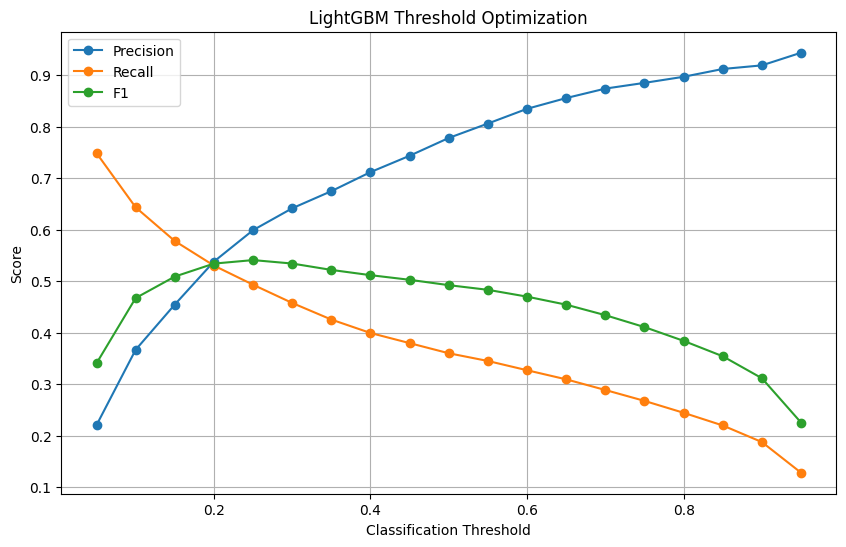

In [142]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results_lgb["Threshold"],
    threshold_results_lgb["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results_lgb["Threshold"],
    threshold_results_lgb["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results_lgb["Threshold"],
    threshold_results_lgb["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("LightGBM Threshold Optimization")
plt.legend()
plt.grid(True)

plt.show()

### Inference

The graph clearly shows the expected **precision–recall trade-off** for LightGBM:

- As the **threshold increases**, precision consistently increases while recall decreases.
- At low thresholds, the model flags more transactions as potentially fraudulent, resulting in **higher fraud detection but more false positives**.
- Around **0.20–0.25**, precision and recall are relatively balanced.
- **F1 peaks around 0.25**, confirming that this region provides the strongest balance between precision and recall among the tested thresholds.
- At the default **0.50 threshold**, precision is strong, but recall has already dropped considerably.
- At very high thresholds, precision becomes excellent, but the model misses a large proportion of fraudulent transactions.

### Key Conclusion

> **The classification threshold is a business decision, not simply a model default.**

The visualization confirms that lowering the threshold can substantially increase fraud detection while accepting more false alerts.

However, **we will not select 0.25 solely because it has the highest F1**. The next step is to compare the candidate operating points and then determine the threshold using **business-cost analysis**.


### STEP 8.3 | Identify Candidate Thresholds

We now know from the graph that the useful operating region is roughly 0.20–0.30.

Instead of choosing a threshold visually, we'll identify the strongest candidates quantitatively.

We'll look at:

1. Highest F1
2. Thresholds with Precision ≥ 50%
3. Thresholds with Recall ≥ 50%

This gives us objective candidates before we bring in business cost.

In [143]:
# Best thresholds according to F1
best_f1_thresholds = threshold_results_lgb.sort_values(
    "F1",
    ascending=False
).head(5)

print("Top 5 thresholds by F1:")
display(best_f1_thresholds.round(4))

# Thresholds with both precision and recall >= 50%
balanced_thresholds = threshold_results_lgb[
    (threshold_results_lgb["Precision"] >= 0.50) &
    (threshold_results_lgb["Recall"] >= 0.50)
]

print("Thresholds with both Precision and Recall >= 50%:")
display(balanced_thresholds.round(4))

Top 5 thresholds by F1:


,Threshold,Precision,Recall,F1,Alerts
4,0.25,0.5991,0.4931,0.5410,3345
5,0.30,0.6416,0.4577,0.5343,2899
3,0.20,0.5381,0.5303,0.5341,4005
6,0.35,0.6749,0.4254,0.5219,2562
7,0.40,0.7118,0.3994,0.5117,2280


Thresholds with both Precision and Recall >= 50%:


,Threshold,Precision,Recall,F1,Alerts
3,0.2,0.5381,0.5303,0.5341,4005


### Inference

The quantitative analysis confirms that **0.20–0.30** is the most useful operating region.

- **0.25** gives the highest F1 of **54.10%** among the tested thresholds.
- **0.20** is the **only tested threshold** where both precision and recall are at least **50%**.
- At **0.20**, the model achieves:
  - **Precision:** 53.81%
  - **Recall:** 53.03%
  - **F1:** 53.41%
  - **Alerts:** 4,005
- At **0.25**, precision improves to **59.91%**, but recall decreases to **49.31%**.
- At **0.30**, precision increases further to **64.16%**, while recall falls to **45.77%**.

### Key Conclusion

 **Thresholds around 0.20–0.30 represent the strongest candidate operating region for LightGBM.**

## STEP 9 | BUSINESS COST ANALYSIS

Up to now, we've selected candidate thresholds based on statistical performance.

But a real fraud system has a business question:

Is it worse to miss a fraud, or to incorrectly flag a legitimate transaction?

These are:

False Negative (FN): Fraud → predicted legitimate

False Positive (FP): Legitimate → predicted fraud

### 9.1  Calculate Business Cost

We'll evaluate the candidate thresholds from 0.20 to 0.30.

In [144]:
from sklearn.metrics import confusion_matrix

candidate_thresholds = [0.20, 0.25, 0.30]

FP_COST = 1
FN_COST = 10

business_cost_results = []

for threshold in candidate_thresholds:
    y_pred_threshold = (
        y_validation_proba_lgb_strong >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_validation,
        y_pred_threshold
    ).ravel()

    total_cost = (fp * FP_COST) + (fn * FN_COST)

    business_cost_results.append({
        "Threshold": threshold,
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn,
        "Precision": precision_score(
            y_validation,
            y_pred_threshold,
            zero_division=0
        ),
        "Recall": recall_score(
            y_validation,
            y_pred_threshold,
            zero_division=0
        ),
        "F1": f1_score(
            y_validation,
            y_pred_threshold,
            zero_division=0
        ),
        "Total Cost": total_cost
    })

business_cost_results = pd.DataFrame(business_cost_results)

display(business_cost_results.round(4))

,Threshold,TP,FP,TN,FN,Precision,Recall,F1,Total Cost
0,0.20,2155,1850,112194,1909,0.5381,0.5303,0.5341,20940
1,0.25,2004,1341,112703,2060,0.5991,0.4931,0.5410,21941
2,0.30,1860,1039,113005,2204,0.6416,0.4577,0.5343,23079


### Key Finding

Under the assumed 10:1 FN-to-FP cost ratio, threshold 0.20 produces the lowest total business cost:

    Total Cost = 20,940 units

Although 0.25 has the highest F1, it misses more fraud cases than 0.20. Because we assumed that a missed fraud is 10× more costly than a false alert, those additional false negatives outweigh the reduction in false positives.

### STEP 9.2 | Cost Sensitivity Analysis

We currently know that 0.20 is the best threshold under one assumption:

    FN cost = 10 × FP cost

But that assumption is arbitrary because the dataset doesn't provide actual monetary costs.

In [145]:

cost_ratios = [2, 5, 10, 20, 50]

sensitivity_results = []

for ratio in cost_ratios:
    for threshold in thresholds:
        y_pred_threshold = (
            y_validation_proba_lgb_strong >= threshold
        ).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_validation,
            y_pred_threshold
        ).ravel()

        total_cost = fp + (fn * ratio)

        sensitivity_results.append({
            "FN:FP Cost Ratio": f"{ratio}:1",
            "Threshold": threshold,
            "FP": fp,
            "FN": fn,
            "Total Cost": total_cost
        })

sensitivity_results = pd.DataFrame(sensitivity_results)

best_cost_by_ratio = (
    sensitivity_results
    .loc[
        sensitivity_results.groupby("FN:FP Cost Ratio")["Total Cost"]
        .idxmin()
    ]
    .sort_values("FN:FP Cost Ratio")
    .reset_index(drop=True)
)

display(best_cost_by_ratio.round(4))

,FN:FP Cost Ratio,Threshold,FP,FN,Total Cost
0,10:1,0.10,4515,1449,19005
1,20:1,0.05,10768,1021,31188
2,2:1,0.30,1039,2204,5447
3,50:1,0.05,10768,1021,61818
4,5:1,0.15,2818,1715,11393


### Inference

The cost-sensitivity analysis shows that the optimal threshold depends strongly on the relative business cost of missing fraud versus generating false alerts.

1. When FN:FP = 2:1, the optimal threshold is 0.30, with a total cost of 5,447.
2. When FN:FP = 5:1, the optimal threshold shifts to 0.15, with a total cost of 11,393.
3. When FN:FP = 10:1, the optimal threshold shifts further to 0.10, with a total cost of 19,005.
4. When FN:FP = 20:1, the optimal threshold becomes 0.05, with a total cost of 31,188.
5. When FN:FP = 50:1, the optimal threshold remains 0.05, with a total cost of 61,818.

Key Finding

As the cost of missing a fraudulent transaction increases, the business should generally use a lower classification threshold to catch more potential fraud, accepting a larger number of false alerts.


### STEP 9.3 | Business Cost Interpretation

The key lesson from the sensitivity analysis is:
    There is no single mathematically correct threshold without a defined business cost structure.

The optimal threshold is business-dependent and should be selected using the organization's actual estimated cost of false positives and false negatives.    

### STEP 9.4 — Business Decision Framework

We now know that the optimal threshold changes with the business cost ratio. The next step is to translate that into a practical fraud-detection decision.

A real organization would not say:

"Use 0.10 because our model produced the lowest mathematical cost."

Instead, it would first establish the relative cost of:

    1. False Positive (FP): legitimate transaction sent for investigation
    2. False Negative (FN): fraudulent transaction allowed through

Then the threshold can be selected according to that business objective.

"Threshold selection should ultimately be driven by the organization's actual fraud-loss and investigation-cost estimates rather than by F1 alone."

### STEP 9.5 | Finalize the Business Threshold Framework

At this point, we have enough evidence to establish the correct methodology for threshold selection.

#### Decision

We will **not claim that one threshold is universally optimal**.

Instead, the project will present:

1. **Statistical operating points** — such as **0.20, 0.25, and 0.30**.
2. **Cost-sensitive operating points** — showing how the optimal threshold changes under different **FN:FP cost assumptions**.
3. **Production recommendation** — the threshold should ultimately be selected using the organization's actual **fraud-loss and investigation-cost estimates**.

This is the most defensible approach because the IEEE-CIS dataset does not provide the actual monetary cost of individual fraud losses or investigation costs.

#### What We Have Established

```text
Model Performance
        ↓
Threshold Trade-off
        ↓
Candidate Operating Region
        ↓
Business Cost Sensitivity
        ↓
Threshold Depends on Business Economics
        ↓
Final Threshold Requires Real Business Costs

## STEP 10 — FINAL MODEL SELECTION

### STEP 10.1 — Model Selection Decision

The four evaluated models were compared using their performance on the same untouched chronological validation set.

| Model | Precision | Recall | F1 | PR-AUC | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Logistic Regression | 0.0984 | 0.7729 | 0.1746 | 0.1841 | 0.8311 |
| Random Forest | 0.8723 | 0.2453 | 0.3829 | 0.5262 | 0.8988 |
| XGBoost | 0.7833 | 0.3477 | 0.4816 | 0.5326 | 0.9053 |
| **LightGBM** | **0.7782** | **0.3600** | **0.4923** | **0.5560** | **0.9158** |

### Selection Rationale

- **Logistic Regression** achieved the highest recall but suffered from very low precision, resulting in a large number of false positives.
- **Random Forest** achieved the highest precision but had substantially lower recall and weaker overall ranking performance than the boosting models.
- **XGBoost** provided a strong balance between precision and recall and performed considerably better than Logistic Regression and Random Forest on PR-AUC and ROC-AUC.
- **LightGBM** achieved the highest **F1, PR-AUC, and ROC-AUC** among the four models, making it the strongest overall candidate.

### Final Model Decision

> **LightGBM is selected as the final model candidate.**

This decision is based primarily on its superior overall ranking performance and balanced classification performance on the untouched chronological validation set.

The classification threshold remains a **separate business decision** and should not be confused with model selection. Threshold optimization demonstrated that different operating points can be chosen depending on the relative cost of false positives and false negatives.

### Important Note

The final threshold has **not been declared universally optimal**, because the IEEE-CIS dataset does not provide actual monetary costs for false positives and false negatives.

Therefore, the production threshold should ultimately be determined using the organization's real business cost structure and operational capacity.

### STEP 10.2 — Why LightGBM Over the Other Models?

### What Are We Doing?

We have selected LightGBM as the **final model candidate**. Now we need to make this decision defensible.

The key question is:

> **Why LightGBM, when Random Forest has higher precision and Logistic Regression has much higher recall?**

The answer is that we are evaluating the models as **fraud-risk ranking systems**, rather than selecting a model based on a single metric.

### Model Comparison

- **Logistic Regression** → achieved excellent recall (**77.29%**) but extremely poor precision (**9.84%**). It catches a large proportion of fraud but generates too many false alerts.
- **Random Forest** → achieved excellent precision (**87.23%**) but low recall (**24.53%**). It is conservative and misses a substantial amount of fraud.
- **XGBoost** → provided a much better balance, with **0.5326 PR-AUC** and **0.9053 ROC-AUC**.
- **LightGBM** → achieved the strongest overall performance:
  - **PR-AUC: 0.5560** — highest
  - **ROC-AUC: 0.9158** — highest
  - **F1: 0.4923** — highest
  - **Recall: 36.00%** — highest among the tree-based models
  - **Precision: 77.82%** — still strong

### Why PR-AUC Matters Most

Our dataset is highly imbalanced, with fraud representing only a small fraction of all transactions.

Therefore, **PR-AUC is particularly important** because it evaluates how effectively the model identifies fraudulent transactions while maintaining precision across different classification thresholds.

LightGBM achieved the highest PR-AUC (**0.5560**) among the four models, indicating the strongest overall fraud-ranking capability on our chronological validation set.

### Key Conclusion

> **LightGBM is selected because it provides the strongest overall combination of ranking quality and classification performance, rather than because it has the highest value for every individual metric.**

The classification threshold remains a separate business decision and can be adjusted according to the organization's requirements.

### STEP 10.3 — Final Model Verification

### Objective

Before proceeding to deployment, the selected LightGBM model is verified against the final chronological validation results.

This verification ensures that the model selection decision is based on the correct model, correct validation set, and previously recorded evaluation results.

### Verification Checklist

The following points were verified:

1. **Model:** The selected model is the strongly tuned LightGBM model.

2. **Validation data:** Evaluation was performed on the untouched chronological validation set:
   - Training/development rows: 472,432
   - Final validation rows: 118,108

3. **Evaluation metrics:** The previously obtained validation metrics were:

   | Metric | LightGBM |
   |---|---:|
   | Precision | 0.7782 |
   | Recall | 0.3600 |
   | F1 | 0.4923 |
   | PR-AUC | 0.5560 |
   | ROC-AUC | 0.9158 |

4. **Confusion Matrix:**

   ```text
   [[113627    417]
    [  2601   1463]]